# Paired biopsy–resection RNA-seq analysis


This notebook analyzes paired biopsy and resection RNA-seq profiles from HCC
patients. Non-tumor liver and tumor samples are modeled separately after shared
sample validation and gene annotation. The workflow includes sequencing QC,
variance-stabilizing transformation (VST), PCA, paired PCA-distance analyses,
patient-blocked permutation tests, paired differential expression, pathway
enrichment, and cross-tissue significant-gene overlap.

**Primary inputs**

- `../counts_080725.out`: featureCounts-style gene-count table.
- `../sample_mapping_BvR.csv`: patient, sample, clinical, and tissue-composition mapping.
- `../../../ensemble_mappings_biotype.pkl` and `../../../ensemble_mappings_gene.pkl`:
  Ensembl biotype and gene-symbol mappings.

**Key analysis settings**

- Protein-coding genes only.
- A gene is retained when it has at least 10 counts in at least three samples.
- PCA uses the 500 most variable genes and up to 10 principal components.
- Biopsy/resection labels are permuted within patient for collection-method tests.
- Patient C is excluded from the reshaped RNA metadata because of the long interval
  between biopsy and resection.

## 1. Environment and imports

Load analysis, statistics, plotting, enrichment, and PyDESeq2 dependencies.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy import stats
import pingouin

import numpy as np
import pandas as pd
import os
import pickle
import statistics
import csv
import itertools

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from statsmodels.stats.multitest import multipletests
from scipy.stats import linregress
from scipy.spatial.distance import pdist
from scipy.stats import percentileofscore

import matplotlib.pyplot as plt
from matplotlib.pyplot import gcf
import matplotlib
from matplotlib import cm, colors
import seaborn as sns

from gseapy.plot import barplot, dotplot
import gseapy as gp
from gseapy import Msigdb

matplotlib.rc('pdf', fonttype=42)

sns.set(font_scale=1.5)
sns.set_style("ticks")

## 2. Plotting configuration

Define the logarithmic color normalization and preview the palette used in downstream figures.

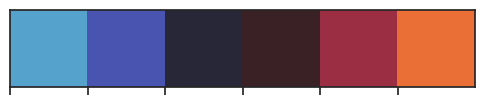

In [4]:
import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=10, vmax=240)

palette = sns.color_palette('icefire')
sns.palplot(palette)
plt.savefig('icefire_cmap.pdf')

## 3. Analysis constants

Central settings for the number of variable genes, PCA dimensions, permutations, and random seed.

In [5]:
N_TOP_GENES = 500
N_PCS = 10
RANDOM_STATE = 1

In [6]:
# Parameters
hue_order=['Biopsy', 'Resection']

## 4. Load the RNA-seq count matrix

Read the featureCounts table, remove feature-annotation columns, and standardize sample identifiers.

In [7]:
# Import data

raw = pd.read_csv('../counts_080725.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw = raw.iloc[:,5:]
# Change column names
raw.columns = raw.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw.head()

,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,BSSE_QGF_129474,BSSE_QGF_129475,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129478,BSSE_QGF_129479,...,BSSE_QGF_182105,BSSE_QGF_182106,BSSE_QGF_182107,BSSE_QGF_182108,BSSE_QGF_182109,BSSE_QGF_182110,BSSE_QGF_182111,BSSE_QGF_55728,BSSE_QGF_55730,BSSE_QGF_55744
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,531,285,307,158,589,289,268,169,243,...,231,261,1579,276,1251,445,279,127,491,217
ENSG00000279928,1,1,0,3,0,1,1,22,2,1,...,3,0,2,1,4,0,0,2,4,1
ENSG00000228037,13,11,10,0,12,13,24,17,3,2,...,2,5,43,5,23,8,3,14,16,12
ENSG00000142611,40,9,50,5,18,20,92,66,19,10,...,79,13,6,4,67,5,5,4,73,66
ENSG00000284616,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6


## 5. Select mapped HCC samples

Load the sample mapping, retain HCC patients with a complete set of four RNA-seq samples, and confirm sample coverage.

In [8]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
rna_cols = ['Biopsy_nt_transcriptome', 'Biopsy_tu_transcriptome',
            'Resection_nt_transcriptome', 'Resection_tu_transcriptome']
meta = meta.dropna(subset=rna_cols)
meta.head()



,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,...,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
3,B,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,NaN,NaN,NaN,NaN,NaN,...,16.0,6.0,86.0,99.0,8.0,0.0,0.0,1.0,5.0,0.0
5,C,BSSE_QGF_145480,BSSE_QGF_145481,BSSE_QGF_182091,BSSE_QGF_182092,001_BR-LF-3_C21,002_BR-LF-3_C21,041_BR-LF-3_C21,042rr_BR-LF-3_C21,001_BR-LF-3P_PO4_C21,...,38.0,9.0,92.0,98.0,8.0,0.0,0.0,2.0,0.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,...,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,...,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,...,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0


In [9]:
# Check if we have all rna seq samples in the counts table
found = []
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)

In [10]:
# Extras
extras = []
for seq_id in raw.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
raw_ = raw.drop(extras, axis=1)

extra: BSSE_QGF_145457
extra: BSSE_QGF_145458
extra: BSSE_QGF_145465
extra: BSSE_QGF_145466
extra: BSSE_QGF_182046
extra: BSSE_QGF_182047
extra: BSSE_QGF_182048
extra: BSSE_QGF_182049
extra: BSSE_QGF_182056
extra: BSSE_QGF_182057
extra: BSSE_QGF_182080
extra: BSSE_QGF_182081
extra: BSSE_QGF_182087
extra: BSSE_QGF_182088
extra: BSSE_QGF_182108
extra: BSSE_QGF_182109


## 6. Annotate and filter genes

Map Ensembl identifiers to biotypes and retain protein-coding genes for the downstream analysis.

In [11]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = raw_.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [12]:
df_bt.head()

,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,BSSE_QGF_129474,BSSE_QGF_129475,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129478,BSSE_QGF_129479,...,BSSE_QGF_182104,BSSE_QGF_182105,BSSE_QGF_182106,BSSE_QGF_182107,BSSE_QGF_182110,BSSE_QGF_182111,BSSE_QGF_55728,BSSE_QGF_55730,BSSE_QGF_55744,Biotype
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,531,285,307,158,589,289,268,169,243,...,201,231,261,1579,445,279,127,491,217,protein_coding
ENSG00000279928,1,1,0,3,0,1,1,22,2,1,...,0,3,0,2,0,0,2,4,1,transcribed_unprocessed_pseudogene
ENSG00000228037,13,11,10,0,12,13,24,17,3,2,...,0,2,5,43,8,3,14,16,12,lncRNA
ENSG00000142611,40,9,50,5,18,20,92,66,19,10,...,13,79,13,6,5,5,4,73,66,protein_coding
ENSG00000284616,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,6,lncRNA


In [13]:
# Take only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc.index.name = None
df_pc.shape

(20056, 65)

In [14]:
meta.columns

Index(['Patient ID', 'Biopsy_nt_transcriptome', 'Biopsy_tu_transcriptome',
       'Resection_nt_transcriptome', 'Resection_tu_transcriptome',
       'Biopsy_nt_proteome', 'Biopsy_tu_proteome', 'Resection_nt_protome',
       'Resection_tu_protome', 'Biopsy_nt_phospho', 'Biopsy_tu_phospho',
       'Resection_nt_phospho', 'Resection_tu_phospho', 'Age', 'Sex',
       'PreBx_MELD', 'PreBx_ALAT', 'PreBx_ASAT', 'PreBx_GGT', 'PreBx_AP',
       'PreBx_Albumin', 'PreBx_Bilirubin', 'PreBx_Quick', 'PreBx_Hb',
       'PreBx_Lc', 'PreBx_Tc', 'PreBx_CRP', 'PreBx_AFP', 'PreOP_MELD',
       'PreOP_ALAT', 'PreOP_ASAT', 'PreOP_GGT', 'PreOP_AP', 'PreOP_Albumin',
       'PreOP_Bilirubin', 'PreOP_Quick', 'PreOP_Hb', 'PreOP_Lc', 'PreOP_Tc',
       'PreOP_CRP', 'PreOP_AFP', 'CHILD', 'BCLC', 'Nr of nodules',
       'Max nodule size', 'Time between resection and biopsy',
       'Total surgery time = ischemia time', 'Tumor diagnosis',
       'Biopsy_nt_hepatocyte', 'Resection_nt_hepatocyte', 'Biopsy_nt_stroma',


## 7. Reshape sample and tissue-composition metadata

Convert wide sample columns to one row per sample, attach tissue-composition estimates, and align metadata with the count matrix.

In [15]:
# tissue composition cols
tissue_comp_cols = ["Biopsy_nt_hepatocyte", "Resection_nt_hepatocyte", "Biopsy_nt_stroma",
                     "Resection_nt_stroma", "Biopsy_tu_tumor", "Resection_tu_tumor", "Biopsy_tu_stroma",
                     "Resection_tu_stroma", "Biopsy_tu_necrosis", "Resection_tu_necrosis", "Biopsy_tu_nontumor",
                     "Resection_tu_nontumor"]


meta_rna = meta.loc[:,['Patient ID', 'Biopsy_nt_transcriptome',
       'Biopsy_tu_transcriptome', 'Resection_nt_transcriptome',
       'Resection_tu_transcriptome','Age', 'Sex','Time between resection and biopsy',
       'Total surgery time = ischemia time'] + tissue_comp_cols].copy()
meta_rna_seq = meta_rna.melt(id_vars=['Patient ID', 'Age', 'Sex',
                                  'Time between resection and biopsy',
                                  'Total surgery time = ischemia time'],
                         value_vars=['Biopsy_nt_transcriptome',
                                     'Biopsy_tu_transcriptome', 
                                     'Resection_nt_transcriptome',
                                     'Resection_tu_transcriptome'])
meta_rna_tissue = meta_rna.melt(id_vars=['Patient ID'],
                         value_vars=tissue_comp_cols)
meta_rna_tissue['Sample_type'] = meta_rna_tissue.variable.str.split('_').str[0]
meta_rna_tissue['Tissue'] = np.where(meta_rna_tissue.variable.str.contains('_nt_'), 'non-tumor', 'tumor')
meta_rna_tissue = meta_rna_tissue[meta_rna_tissue.Tissue == 'tumor']

meta_rna_seq['Sample_type'] = meta_rna_seq.variable.str.split('_').str[0]
meta_rna_seq['Tissue'] = np.where(meta_rna_seq.variable.str.contains('nt'), 'non-tumor', 'tumor')
meta_rna_seq = meta_rna_seq.drop('variable', axis=1)
meta_rna_seq = meta_rna_seq.rename({'value':'Seq_id', 'Total surgery time = ischemia time': 'Total surgery time',
                           'Patient ID': 'patient_id'}, axis=1)
# # Map Batch from previous metadata
# meta_rna['batch'] = meta_rna.Seq_id.map(meta_old.Batch)
# meta_rna.batch = meta_rna.batch.fillna(1).astype(int)

# biopsy dont have surgery time
meta_rna_seq['Total surgery time'] = np.where(meta_rna_seq['Sample_type'] == 'Biopsy',
                                          0, meta_rna_seq['Total surgery time'])

# Patint C has a very long tim ebwteen Biopsy and resection
meta_rna_seq = meta_rna_seq[meta_rna_seq.patient_id != 'C']

meta_rna_seq.patient_id.unique()

array(['B', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'L', 'N', 'O', 'P', 'Q',
       'T', 'U'], dtype=object)

In [16]:
meta_rna_tissue['variable'] = meta_rna_tissue['variable'].str.split('_').str[-1]

In [17]:
meta_rna_tissue.head()

,Patient ID,variable,value,Sample_type,Tissue
64,B,tumor,86.0,Biopsy,tumor
65,C,tumor,92.0,Biopsy,tumor
66,D,tumor,47.0,Biopsy,tumor
67,E,tumor,61.0,Biopsy,tumor
68,F,tumor,75.0,Biopsy,tumor


In [18]:
meta_rna_tissue_p = meta_rna_tissue.pivot(columns='variable',
                                        index=['Patient ID', 'Sample_type'],
                                        values='value')
meta_rna_tissue_p['total'] = meta_rna_tissue_p.sum(axis=1)

In [19]:
meta_rna_tissue_p = meta_rna_tissue_p.reset_index()
meta_rna_tissue_p.index = meta_rna_tissue_p['Patient ID'] + '_' + meta_rna_tissue_p['Sample_type']
meta_rna_tissue_p = meta_rna_tissue_p.drop('Sample_type', axis=1)
meta_rna_tissue_p.head()

variable,Patient ID,necrosis,nontumor,stroma,tumor,total
B_Biopsy,B,0.0,5.0,8.0,86.0,99.0
B_Resection,B,1.0,0.0,0.0,99.0,100.0
C_Biopsy,C,0.0,0.0,8.0,92.0,100.0
C_Resection,C,2.0,0.0,0.0,98.0,100.0
D_Biopsy,D,0.0,24.0,29.0,47.0,100.0


In [20]:
meta_rna_seq_ = meta_rna_seq.copy()
meta_rna_seq_.index = meta_rna_seq_['patient_id'] + '_' + meta_rna_seq_['Sample_type']
meta_rna = meta_rna_seq_.merge(meta_rna_tissue_p, left_index=True, right_index=True).reset_index()
#meta_rna.index = meta_rna.Seq_id
#meta_rna = meta_rna.drop(['Patient ID', 'total'], axis=1)
meta_rna.head()

,index,patient_id,Age,Sex,Time between resection and biopsy,Total surgery time,Seq_id,Sample_type,Tissue,Patient ID,necrosis,nontumor,stroma,tumor,total
0,B_Biopsy,B,59.0,M,43.0,0.0,BSSE_QGF_129466,Biopsy,non-tumor,B,0.0,5.0,8.0,86.0,99.0
1,D_Biopsy,D,70.0,F,29.0,0.0,BSSE_QGF_182052,Biopsy,non-tumor,D,0.0,24.0,29.0,47.0,100.0
2,E_Biopsy,E,79.0,M,31.0,0.0,BSSE_QGF_145476,Biopsy,non-tumor,E,5.0,15.0,19.0,61.0,100.0
3,F_Biopsy,F,49.0,M,11.0,0.0,BSSE_QGF_145472,Biopsy,non-tumor,F,14.0,0.0,10.0,75.0,99.0
4,H_Biopsy,H,69.0,F,20.0,0.0,BSSE_QGF_129476,Biopsy,non-tumor,H,0.0,0.0,2.0,98.0,100.0


In [21]:
meta_rna.shape

(60, 15)

In [22]:
# Drop these columns also from sequencing dataframe
drops = []
for col in df_pc.columns:
    if col in meta_rna.Seq_id.tolist():
        continue
    else:
        drops.append(col)
        print(col)
df_pc = df_pc.drop(drops, axis=1)

BSSE_QGF_145480
BSSE_QGF_145481
BSSE_QGF_182091
BSSE_QGF_182092
Biotype


## 8. Separate tumor and non-tumor samples

Tumor and non-tumor samples are analyzed separately because their dominant biological differences would obscure within-tissue biopsy/resection effects and distort shared dispersion estimates.

In [23]:
metadata = meta_rna.loc[:,['Sample_type', 'Sex', 'Age', 'Tissue',
                           'Seq_id', 'patient_id',
                           'Time between resection and biopsy',
                           'Total surgery time', "necrosis", "nontumor", "stroma", "tumor", "total"]].copy()
metadata.index = metadata.Seq_id
metadata_liver = metadata[metadata.Tissue == 'non-tumor'].copy()
metadata_hcc = metadata[metadata.Tissue == 'tumor'].copy()


## 9. Sequencing quality control

Join STAR alignment metrics to the sample metadata, visualize mapping categories, and test paired biopsy/resection QC differences.

In [24]:
# QC

star_qc = pd.read_csv('star_alignment_plot.csv', index_col=0, )
star_qc.head()

,Uniquely mapped,Mapped to multiple loci,Mapped to too many loci,Unmapped: too short,Unmapped: other
Category,,,,,
BSSE_QGF_129466,87649491,36706106,191751,1594725,113909
BSSE_QGF_129467,108652373,14717948,127614,1880319,150426
BSSE_QGF_129468,88220083,26541092,190914,1339382,116468
BSSE_QGF_129469,85237280,12956213,113344,1253497,79587
BSSE_QGF_129474,68773205,55606441,190207,1755783,88421


In [25]:
star_qc = star_qc[star_qc.index.isin(metadata.index)]
#star_qc

In [26]:
metadata_qc = pd.concat([metadata, star_qc], axis=1)
metadata_qc.columns

Index(['Sample_type', 'Sex', 'Age', 'Tissue', 'Seq_id', 'patient_id',
       'Time between resection and biopsy', 'Total surgery time', 'necrosis',
       'nontumor', 'stroma', 'tumor', 'total', 'Uniquely mapped',
       'Mapped to multiple loci', 'Mapped to too many loci',
       'Unmapped: too short', 'Unmapped: other'],
      dtype='object')

In [27]:
metadata_qc_ = metadata_qc.loc[:,['Sample_type', 'Uniquely mapped', 'Mapped to multiple loci', 'Mapped to too many loci',
       'Unmapped: too short', 'Unmapped: other']].reset_index().copy()

metadata_qc_ = metadata_qc_.melt(id_vars=['index', 'Sample_type'])
metadata_qc_.head()

,index,Sample_type,variable,value
0,BSSE_QGF_129466,Biopsy,Uniquely mapped,87649491.0
1,BSSE_QGF_182052,Biopsy,Uniquely mapped,56339879.0
2,BSSE_QGF_145476,Biopsy,Uniquely mapped,32130365.0
3,BSSE_QGF_145472,Biopsy,Uniquely mapped,36361834.0
4,BSSE_QGF_129476,Biopsy,Uniquely mapped,74062522.0


Text(0, 0.5, '# reads')

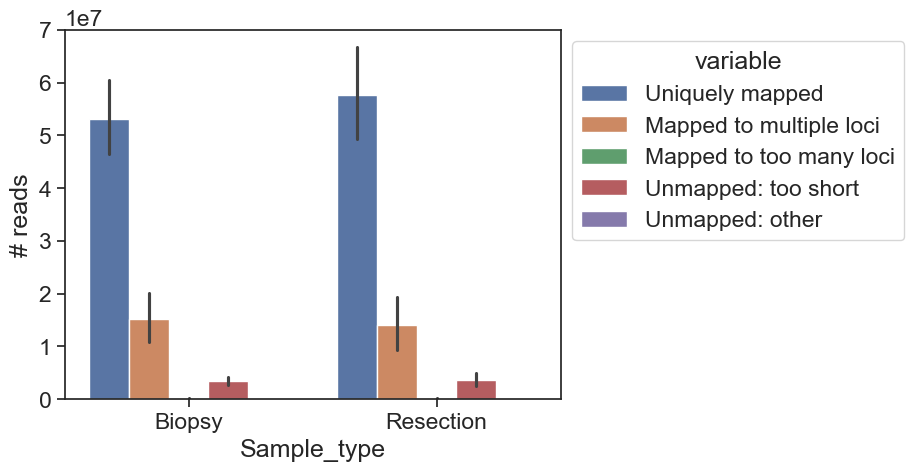

In [28]:
ax = sns.barplot(data=metadata_qc_, x='Sample_type', y='value', hue='variable')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.ylabel('# reads')

#plt.savefig('figures/Transcriptomics_qc.pdf', bbox_inches='tight', dpi=300)

In [29]:
metadata_qc_nona = metadata_qc_.dropna(axis=0).copy()

In [30]:
metadata_qc_nona

,index,Sample_type,variable,value
0,BSSE_QGF_129466,Biopsy,Uniquely mapped,87649491.0
1,BSSE_QGF_182052,Biopsy,Uniquely mapped,56339879.0
2,BSSE_QGF_145476,Biopsy,Uniquely mapped,32130365.0
3,BSSE_QGF_145472,Biopsy,Uniquely mapped,36361834.0
4,BSSE_QGF_129476,Biopsy,Uniquely mapped,74062522.0
...,...,...,...,...
294,BSSE_QGF_182085,Resection,Unmapped: other,71969.0
295,BSSE_QGF_182101,Resection,Unmapped: other,121692.0
297,BSSE_QGF_182103,Resection,Unmapped: other,47385.0
298,BSSE_QGF_182105,Resection,Unmapped: other,30113.0


In [31]:
res_list = []
for var in metadata_qc_nona.variable.unique():
    subset = metadata_qc_nona[metadata_qc_nona.variable == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].value, subset[subset.Sample_type == 'Resection'].value)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

# with open('transcriptomics_qc_ttest.csv', 'w', newline='') as myfile:
#     wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
#     wr.writerow(res_list)

Uniquely mapped
TtestResult(statistic=np.float64(-0.7586414026256468), pvalue=np.float64(0.45130600677696997), df=np.float64(55.0))


Mapped to multiple loci
TtestResult(statistic=np.float64(0.29300987910485654), pvalue=np.float64(0.7706172868267169), df=np.float64(55.0))


Mapped to too many loci
TtestResult(statistic=np.float64(-1.052821202323181), pvalue=np.float64(0.29702648153905065), df=np.float64(55.0))


Unmapped: too short
TtestResult(statistic=np.float64(-0.3468272536457285), pvalue=np.float64(0.7300446277956899), df=np.float64(55.0))


Unmapped: other
TtestResult(statistic=np.float64(-0.6236043963098138), pvalue=np.float64(0.5354652219005235), df=np.float64(55.0))




## 10. VST and PCA across all retained samples

Apply the count filter, fit PyDESeq2 VST, select variable genes, and inspect the global sample structure.

In [32]:
# Filtering

# Create a copy to work on
df_pc_f = df_pc.copy()

# Apply the filter criteria
for col in df_pc_f.columns:
    df_pc_f[col] = np.where(df_pc_f[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_f['Keep'] = np.where(df_pc_f.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_f[df_pc_f.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_f = df_pc.loc[keep_indices_].copy()

In [33]:
df_pc_f.shape

(16788, 60)

In [34]:
metadata.shape

(60, 13)

In [35]:
# Same sort

df_pc_f = df_pc_f.loc[:,sorted(df_pc_f.columns)]

metadata = metadata.sort_index()

In [36]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_f.T,
    metadata=metadata,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~patient_id + Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_f.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_f.T.index, columns=df_pc_f.T.columns
)
df_all = transformed_counts.T

Fitting size factors...
... done in 0.08 seconds.

Fitting size factors...
... done in 0.10 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 18.73 seconds.



In [37]:
df_all_pca = df_all.copy()
df_all_pca['expression_std'] = df_all_pca.std(axis=1)
df_all_pca = df_all_pca.sort_values('expression_std', ascending=False)
df_all_pca = df_all_pca.iloc[:500,:-1]
df_all_pca.head()

,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,BSSE_QGF_129474,BSSE_QGF_129475,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129478,BSSE_QGF_129479,...,BSSE_QGF_182103,BSSE_QGF_182104,BSSE_QGF_182105,BSSE_QGF_182106,BSSE_QGF_182107,BSSE_QGF_182110,BSSE_QGF_182111,BSSE_QGF_55728,BSSE_QGF_55730,BSSE_QGF_55744
ENSG00000147604,6.639555,6.548236,6.136951,6.357529,6.536352,7.697291,6.779147,6.939540,6.453687,8.321209,...,14.938042,14.336782,15.535323,14.233813,14.273468,14.329865,16.127718,13.599527,13.511401,13.543260
ENSG00000160868,15.915340,9.255109,16.277955,9.825088,15.348792,14.558410,16.344074,16.639292,16.674809,15.322326,...,13.918547,18.006930,16.003964,19.006227,16.802121,18.205258,6.219288,17.414719,6.725299,7.102566
ENSG00000198074,9.461419,4.810769,12.204333,6.173362,10.363337,11.430576,7.214699,8.468167,8.775157,10.077056,...,14.996133,13.088001,16.943720,6.949633,7.441099,5.999846,11.863431,6.880004,16.184256,14.927394
ENSG00000177954,6.918035,6.439772,7.110743,7.493861,6.748073,6.526842,6.896737,6.763844,6.887685,6.592047,...,14.233122,14.385872,14.947273,14.074478,14.475557,14.331482,15.888431,13.656349,13.409817,13.126845
ENSG00000067048,11.124097,7.799499,11.494078,11.984183,10.973936,10.973886,4.322049,4.299813,11.778525,11.418950,...,4.388678,11.708111,11.868583,4.446947,4.722799,11.847862,9.077790,11.214697,11.610807,11.315239


In [38]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_all_pca.T)
pca = PCA(n_components=10)

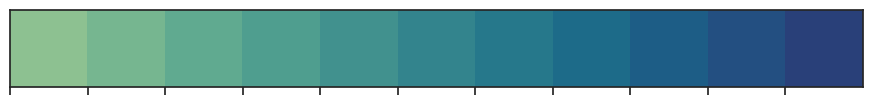

In [39]:
palette = sns.color_palette('crest', 11)
sns.palplot(palette)
plt.savefig('pca_tissue_composition_cmap.pdf')
plt.show()

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:19: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:21: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',


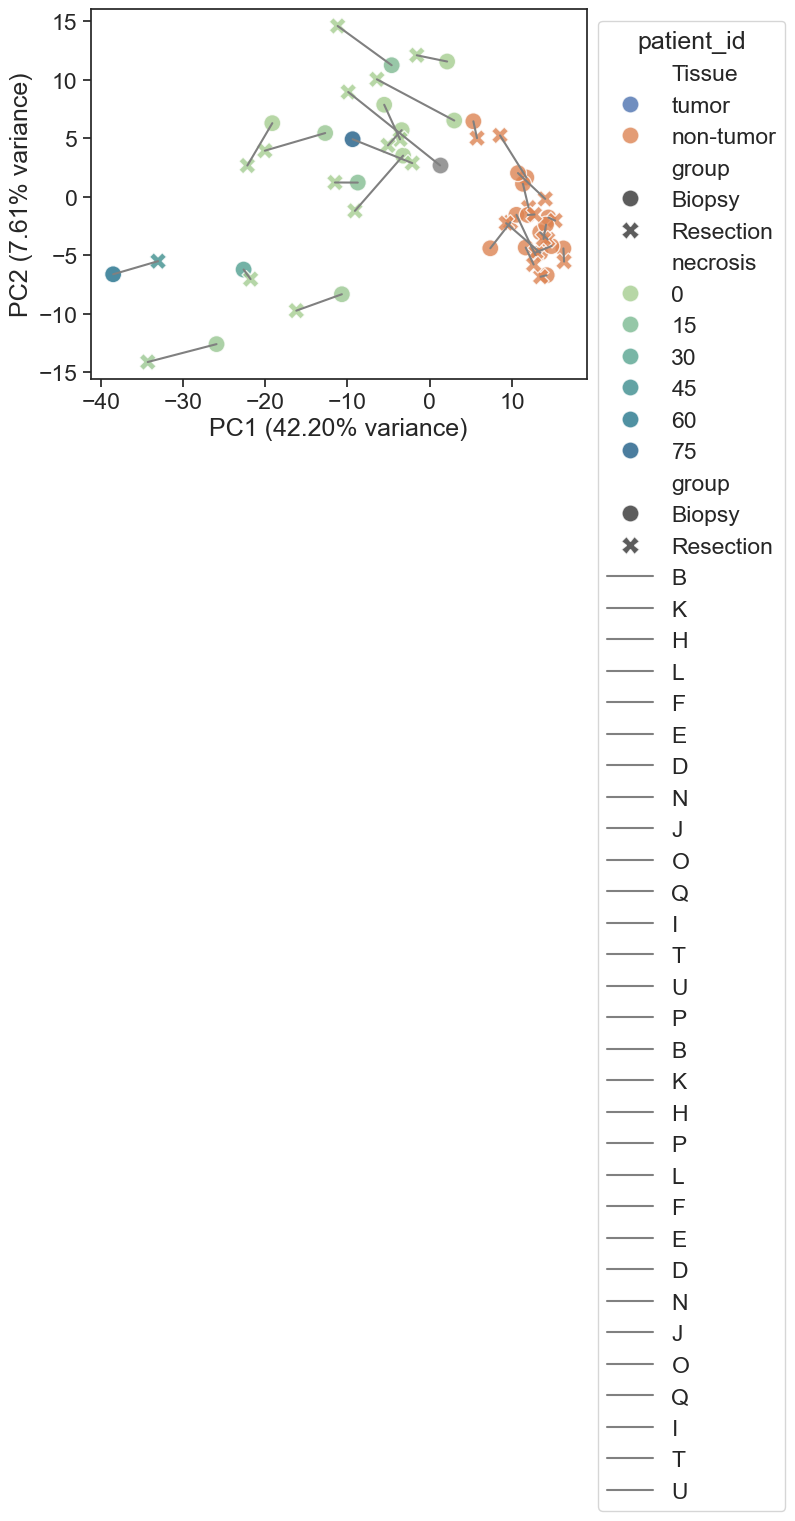

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:19: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:21: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',


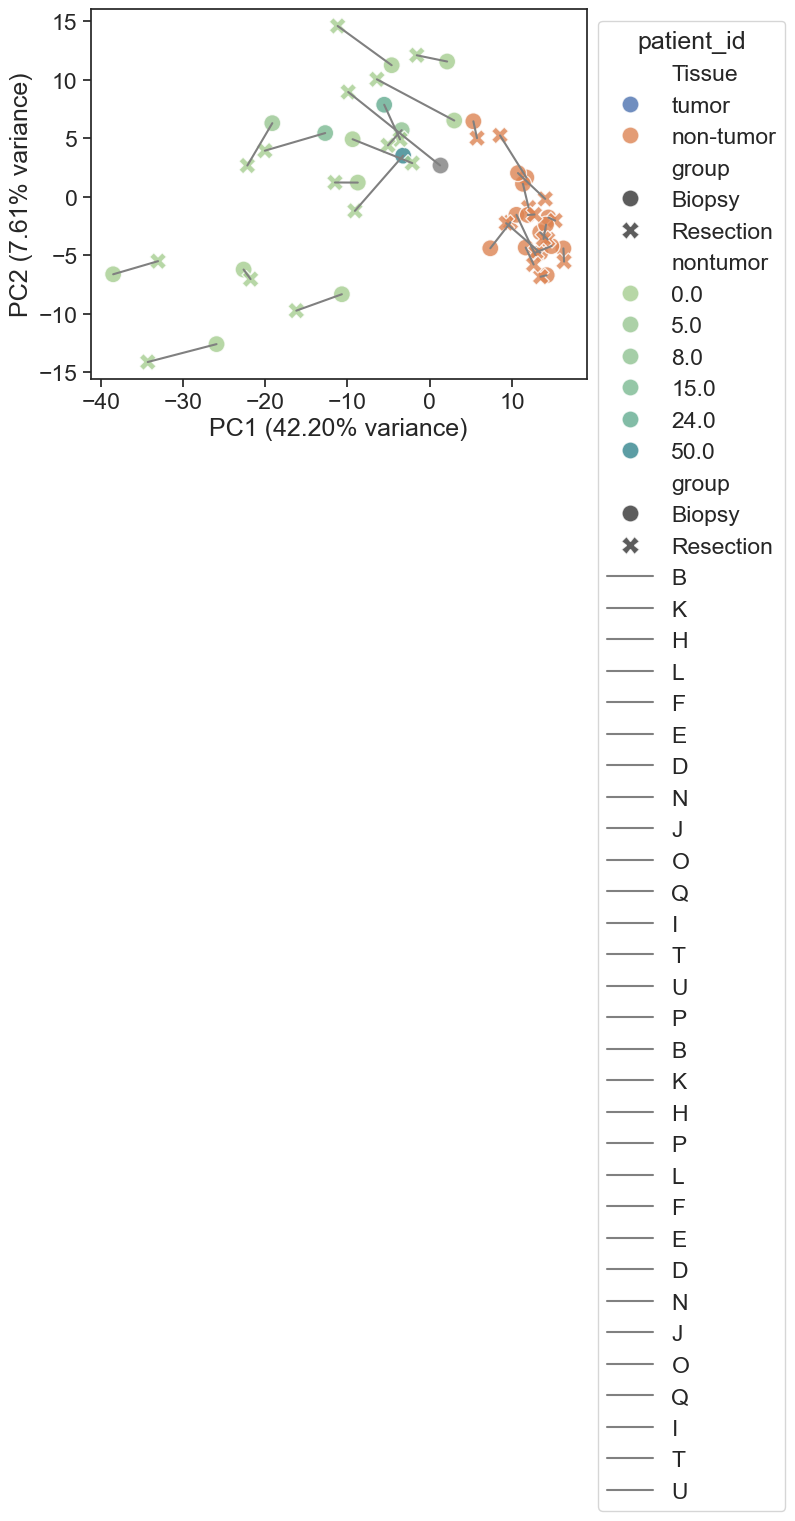

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:19: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:21: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',


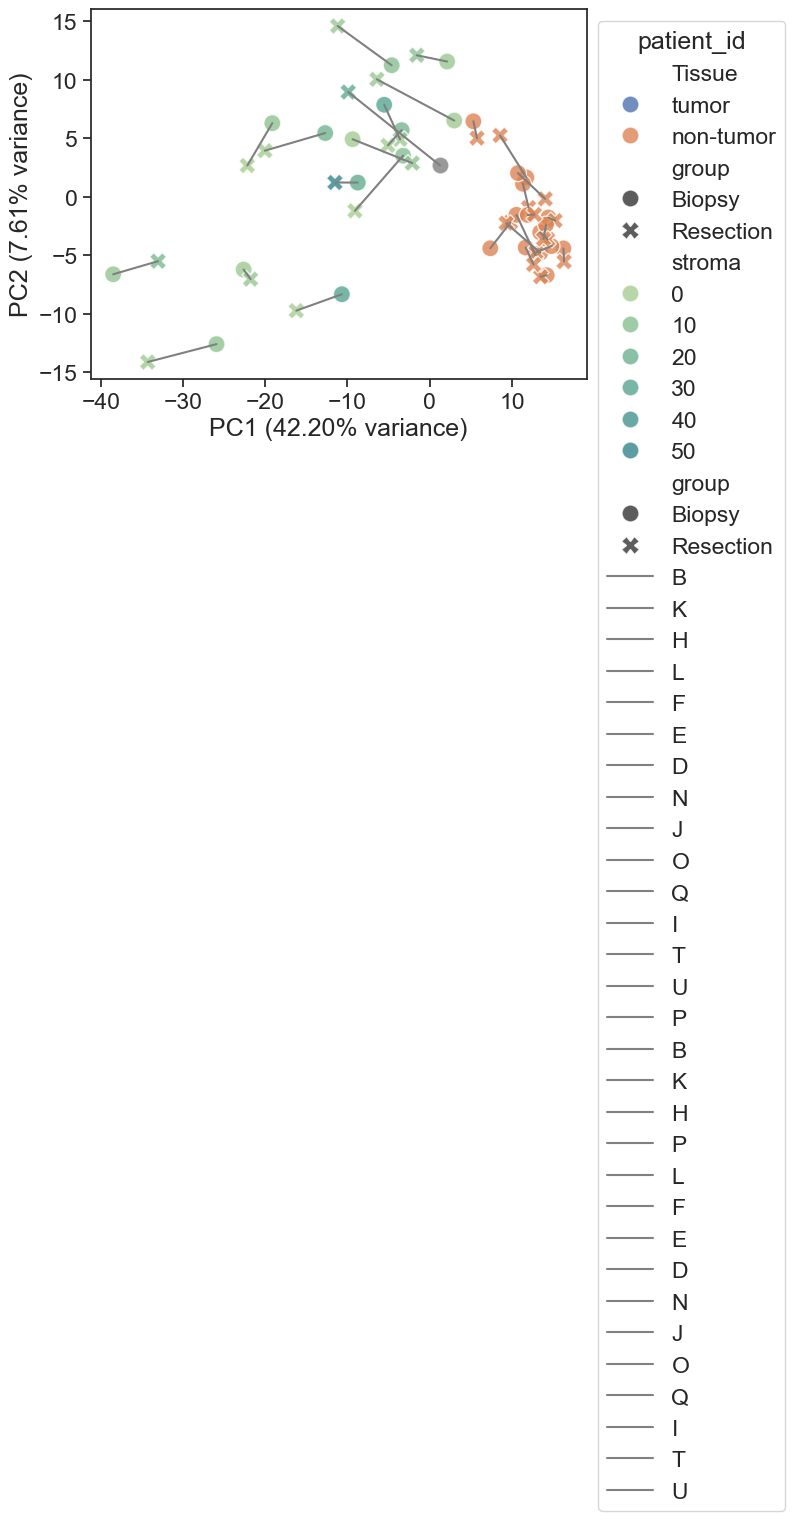

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:19: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:21: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',


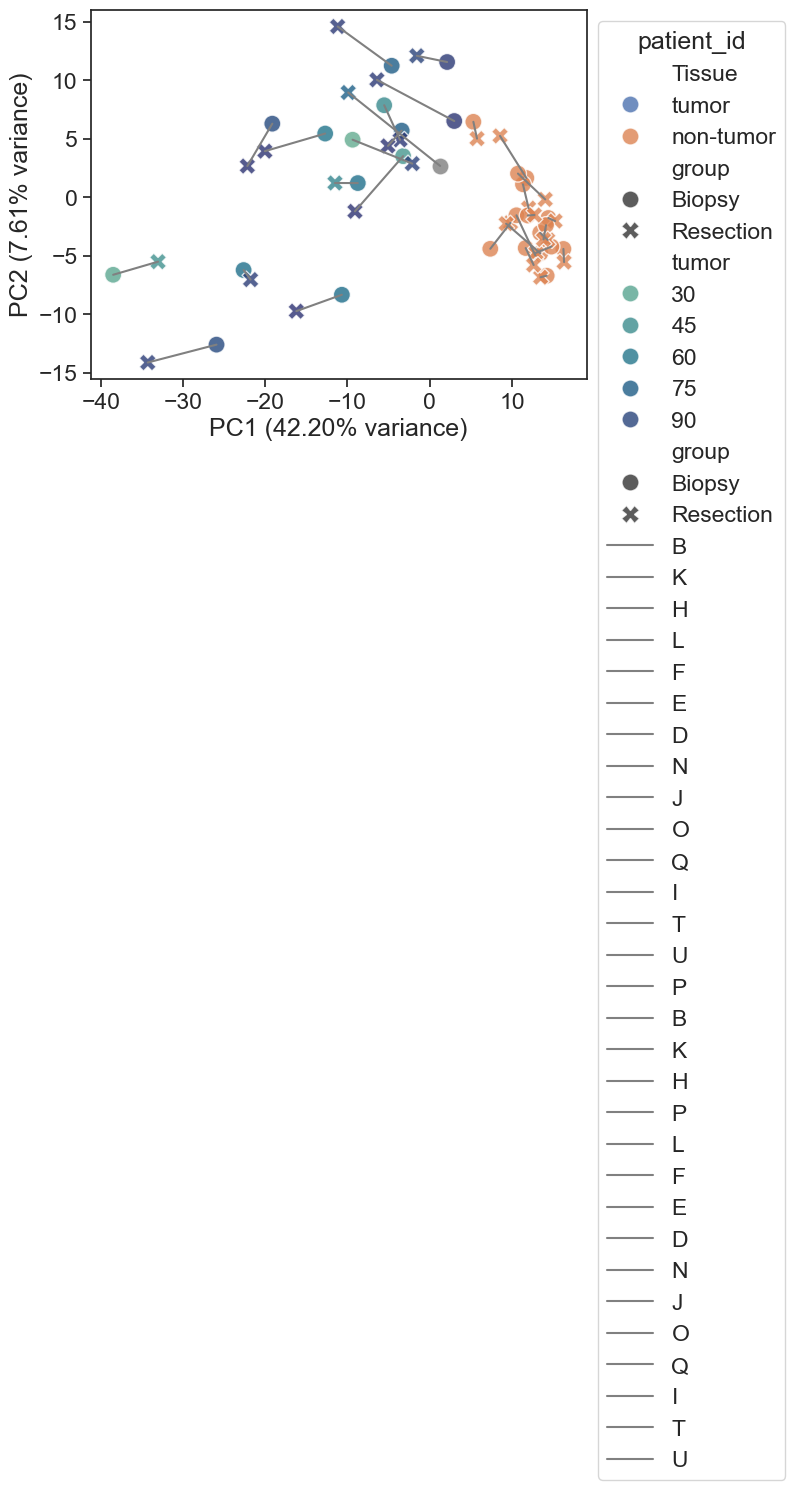

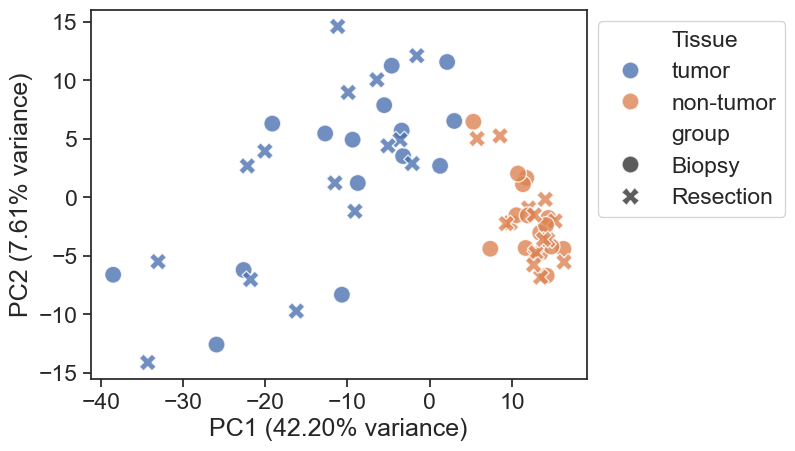

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:48: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\2796073301.py:50: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',


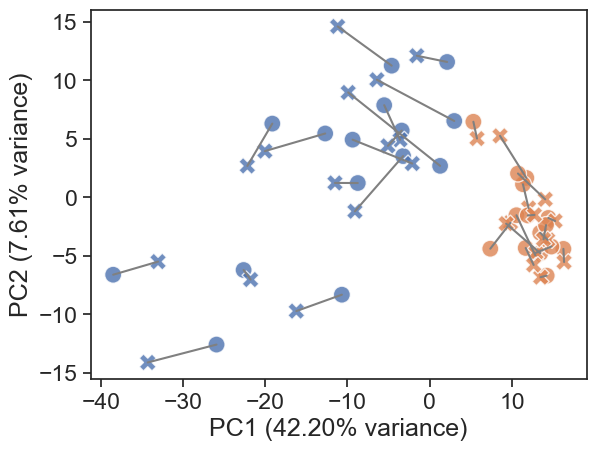

In [40]:
projections = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(projections, columns=[f'PC{x}' for x in range(1,11)], index=df_all_pca.columns)
df_pca['group'] = metadata.Sample_type
df_pca['Tissue'] = metadata.Tissue
df_pca['sex'] = metadata.Sex
df_pca['patient_id'] = metadata.patient_id.astype(str)

for col in ["necrosis", "nontumor", "stroma", "tumor"]:
    df_pca[col] = metadata[col]

    fig, ax = plt.subplots()
    g = sns.scatterplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2', hue='Tissue', style='group',
                        ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
    j = sns.scatterplot(df_pca[df_pca.Tissue == 'tumor'].dropna(), x='PC1', y='PC2', hue_norm=(0,100),
                        hue=col, style='group', ax=ax, s=150, alpha=0.8, palette='crest')
    k = sns.scatterplot(df_pca[(df_pca.Tissue == 'tumor') & (df_pca[col].isna())], x='PC1', y='PC2',c=sns.color_palette(['gray']),
                        ax=ax, s=150, alpha=0.8)
    h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2', 
                     hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
    i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',
                     hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
    #plt.legend([],[], frameon=False)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    plt.savefig(f'figures/PCA_all_{col}.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

    

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Tissue', style='group',
                    ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_all.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Tissue', style='group',
                    ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
                 hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',
                 hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_all_pat.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# Part I — Non-tumor liver

Run the paired non-tumor analysis independently of tumor samples.

In [41]:
metadata_liver.columns

Index(['Sample_type', 'Sex', 'Age', 'Tissue', 'Seq_id', 'patient_id',
       'Time between resection and biopsy', 'Total surgery time', 'necrosis',
       'nontumor', 'stroma', 'tumor', 'total'],
      dtype='object')

In [42]:
df_pc_liver = df_pc.loc[:,metadata_liver.index].copy()

## 11. Non-tumor filtering and VST

Filter genes within the non-tumor subset and calculate the variance-stabilized expression matrix.

In [43]:
# Filtering

# Create a copy to work on
df_pc_liver_f = df_pc_liver.copy()

# Apply the filter criteria
for col in df_pc_liver_f.columns:
    df_pc_liver_f[col] = np.where(df_pc_liver_f[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_liver_f['Keep'] = np.where(df_pc_liver_f.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_liver_f[df_pc_liver_f.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_liver_f = df_pc_liver.loc[keep_indices_].copy()

In [44]:
df_pc_liver_f.shape

(15723, 30)

<Axes: xlabel='total_reads', ylabel='Sample_type'>

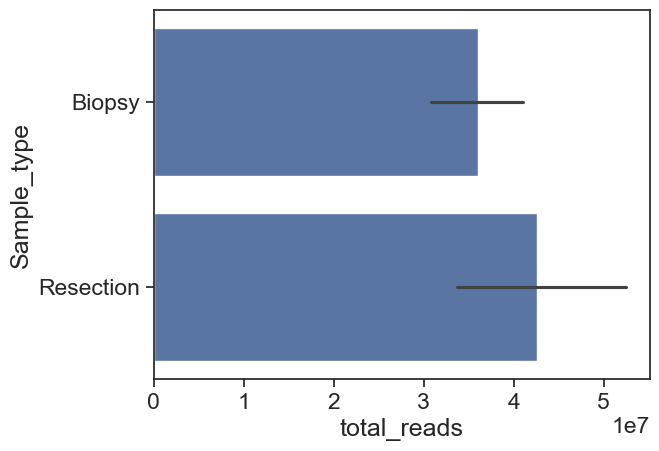

In [45]:
metadata_liver_ = metadata_liver.copy()
metadata_liver_['total_reads'] = df_pc_liver_f.sum()

sns.barplot(data=metadata_liver_, y='Sample_type', x='total_reads')

In [46]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_liver_f.T,
    metadata=metadata_liver,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~patient_id + Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_liver_f.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_liver_f.T.index, columns=df_pc_liver_f.T.columns
)
df_liver = transformed_counts.T

Fitting size factors...
... done in 0.05 seconds.

Fitting size factors...
... done in 0.06 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 15.05 seconds.



In [47]:
df_liver.head()

Seq_id,BSSE_QGF_129466,BSSE_QGF_182052,BSSE_QGF_145476,BSSE_QGF_145472,BSSE_QGF_129476,BSSE_QGF_182072,BSSE_QGF_182064,BSSE_QGF_129474,BSSE_QGF_145460,BSSE_QGF_182054,...,BSSE_QGF_182106,BSSE_QGF_182098,BSSE_QGF_129478,BSSE_QGF_145462,BSSE_QGF_182084,BSSE_QGF_182100,BSSE_QGF_129482,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182110
ENSG00000160072,7.628677,7.220001,7.157348,7.057075,7.795695,7.794800,7.907571,7.261420,7.747785,7.717703,...,7.629980,8.297720,7.192120,7.862069,8.123593,7.500284,7.328699,7.594164,8.021319,8.026734
ENSG00000142611,5.768085,5.059225,4.347859,5.092045,6.565460,4.967678,4.640026,5.477991,6.177095,4.643611,...,5.234824,5.560829,5.437577,6.074409,5.186388,4.347859,4.914741,5.311009,5.522956,4.849865
ENSG00000157911,7.655978,7.186387,7.603541,8.785904,7.243597,8.304344,8.260630,7.970926,7.619202,8.255398,...,7.830879,7.353673,7.192120,7.220063,7.595013,4.347859,7.284435,6.598707,7.872742,7.437269
ENSG00000142655,8.628060,8.388120,8.684634,9.166289,8.352413,8.970732,8.782465,8.872192,8.429772,8.515360,...,8.756878,8.411060,7.857375,8.539144,8.304767,7.983086,7.719221,8.359479,8.557217,8.193970
ENSG00000149527,6.847492,5.647802,5.967643,5.704994,6.369002,6.500375,7.658777,7.456830,6.308577,5.770824,...,5.909195,7.420427,5.612268,6.722535,6.072189,5.839284,5.819443,6.106631,6.127828,7.018764


<Axes: xlabel='total_reads_vst', ylabel='Sample_type'>

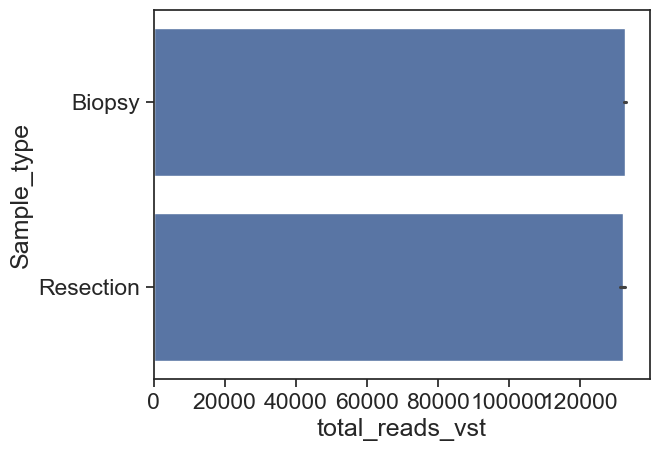

In [48]:
metadata_liver_['total_reads_vst'] = df_liver.sum()

sns.barplot(data=metadata_liver_, y='Sample_type', x='total_reads_vst')

In [49]:
df_liver_pca = df_liver.copy()
df_liver_pca['expression_std'] = df_liver_pca.std(axis=1)
df_liver_pca = df_liver_pca.sort_values('expression_std', ascending=False)
df_liver_pca = df_liver_pca.iloc[:500,:-1]
df_liver_pca.head()

Seq_id,BSSE_QGF_129466,BSSE_QGF_182052,BSSE_QGF_145476,BSSE_QGF_145472,BSSE_QGF_129476,BSSE_QGF_182072,BSSE_QGF_182064,BSSE_QGF_129474,BSSE_QGF_145460,BSSE_QGF_182054,...,BSSE_QGF_182106,BSSE_QGF_182098,BSSE_QGF_129478,BSSE_QGF_145462,BSSE_QGF_182084,BSSE_QGF_182100,BSSE_QGF_129482,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182110
ENSG00000147604,6.555213,14.035627,6.242648,6.493995,6.691017,13.685604,13.394078,6.457229,6.465010,13.862060,...,13.942972,13.443774,6.378174,6.381766,13.882206,13.919158,6.535788,13.486119,14.046544,14.044459
ENSG00000177954,6.805371,13.799442,6.846362,6.748122,6.797279,13.420743,13.189681,6.645736,6.832244,13.705421,...,13.783791,13.490917,6.764371,7.077262,13.892646,13.550383,6.927307,13.593341,14.095594,14.046074
ENSG00000134184,4.347859,4.347859,11.351400,4.347859,10.011931,4.347859,4.347859,4.347859,9.333991,12.156235,...,4.845178,4.347859,4.347859,8.638560,11.027767,5.839284,4.839574,4.665540,11.851586,12.212239
ENSG00000067048,10.854768,4.347859,10.745132,10.841758,4.602173,4.347859,10.849800,10.696160,4.347859,11.346462,...,4.700383,11.143230,11.485700,4.347859,11.976222,11.797078,11.362394,4.895909,11.424188,11.568021
ENSG00000129824,10.548811,4.347859,10.327064,10.868723,4.347859,4.347859,10.743794,10.563858,4.347859,10.832292,...,4.597440,10.509977,11.092960,4.347859,10.700565,10.630732,11.039562,4.665540,10.835979,11.012124


## 12. Non-tumor PCA

Scale the most variable genes, fit PCA, and visualize sample type, patient, sex, timing, and related covariates.

In [50]:
# scaled data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_liver_pca.T)

In [51]:
pca = PCA(n_components=10)

In [52]:
metadata_liver['Time between resection and biopsy']

Seq_id
BSSE_QGF_129466    43.0
BSSE_QGF_182052    29.0
BSSE_QGF_145476    31.0
BSSE_QGF_145472    11.0
BSSE_QGF_129476    20.0
BSSE_QGF_182072    30.0
BSSE_QGF_182064    28.0
BSSE_QGF_129474    27.0
BSSE_QGF_145460    18.0
BSSE_QGF_182054    15.0
BSSE_QGF_182066    28.0
BSSE_QGF_55728     10.0
BSSE_QGF_182070    32.0
BSSE_QGF_182074    19.0
BSSE_QGF_182076    15.0
BSSE_QGF_129468    43.0
BSSE_QGF_182082    29.0
BSSE_QGF_145478    31.0
BSSE_QGF_145474    11.0
BSSE_QGF_129480    20.0
BSSE_QGF_182106    30.0
BSSE_QGF_182098    28.0
BSSE_QGF_129478    27.0
BSSE_QGF_145462    18.0
BSSE_QGF_182084    15.0
BSSE_QGF_182100    28.0
BSSE_QGF_129482    10.0
BSSE_QGF_182102    32.0
BSSE_QGF_182104    19.0
BSSE_QGF_182110    15.0
Name: Time between resection and biopsy, dtype: float64

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\1503786079.py:50: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


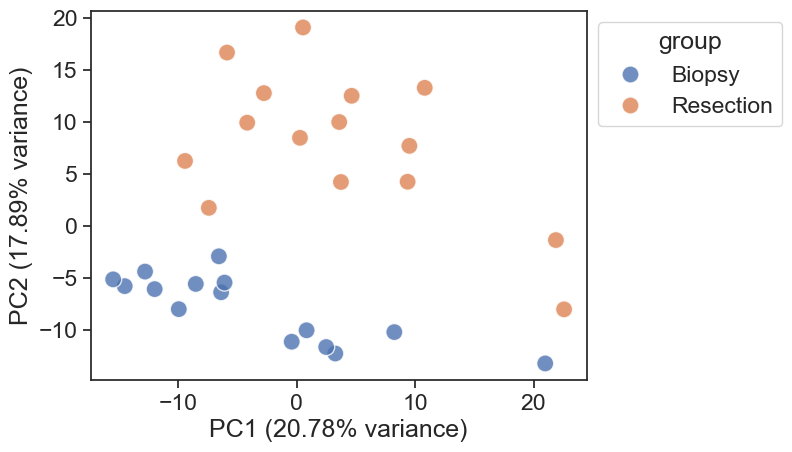

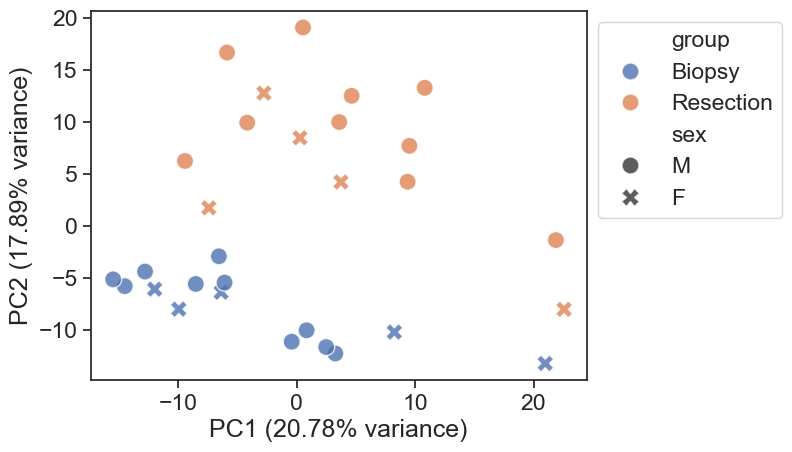

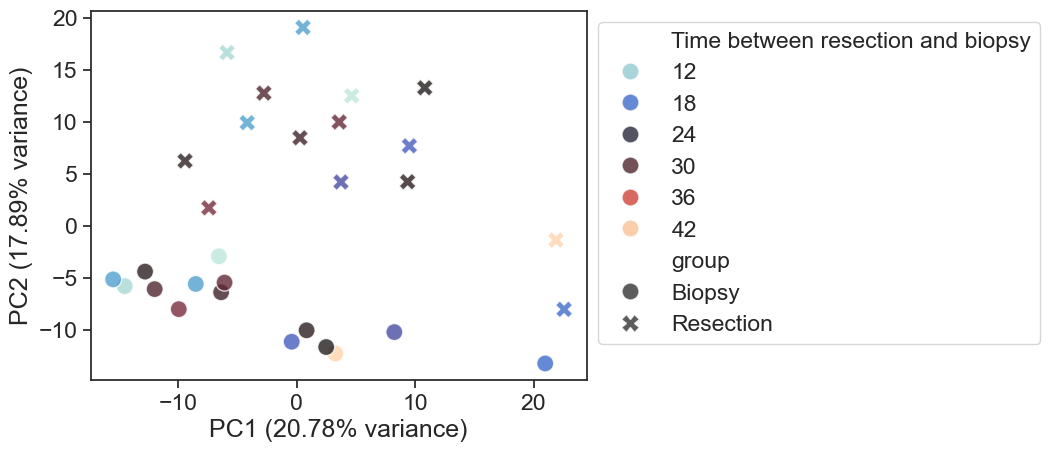

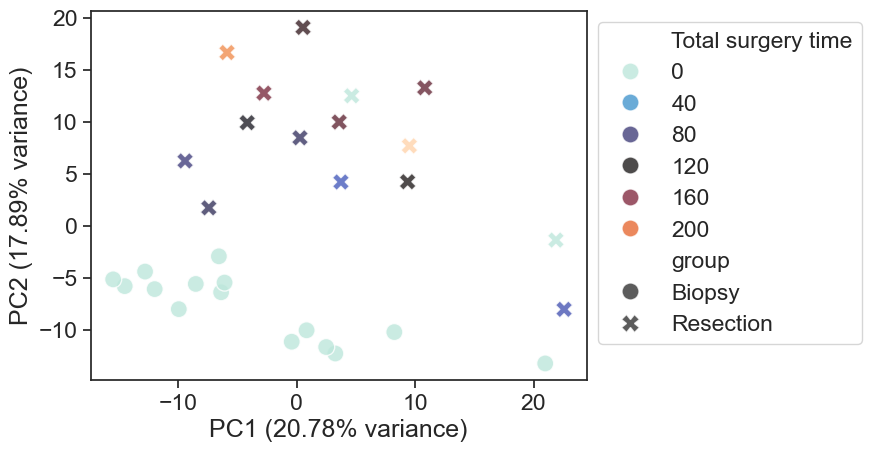

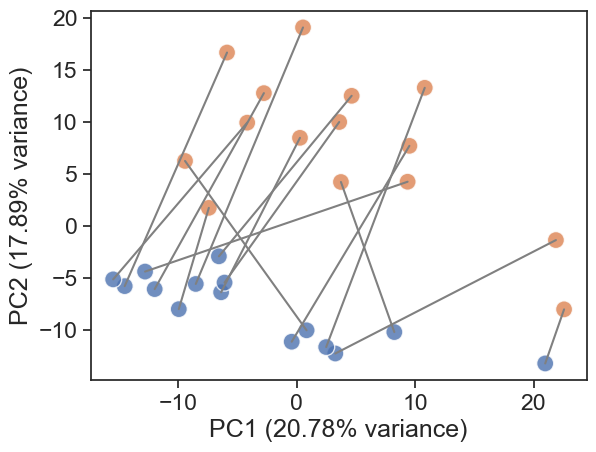

In [53]:
projections = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(projections, columns=[f'PC{x}' for x in range(1,11)], index=df_liver_pca.columns)
df_pca['group'] = metadata_liver.Sample_type
df_pca['sex'] = metadata_liver.Sex
df_pca['patient_id'] = metadata_liver.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_liver['Time between resection and biopsy'].astype(int)
df_pca['Total surgery time'] = metadata_liver['Total surgery time'].fillna(0).astype(int)

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_sex.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_timeBvR.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_surgerytime.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_liver_pat.pdf', bbox_inches='tight', dpi=300)

## 13. Non-tumor PCA–covariate correlations

Examine associations between leading PCs and biopsy-to-resection time or surgical ischemia time.

In [54]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

Text(0.5, 1.0, 'Transcriptome Liver Resections')

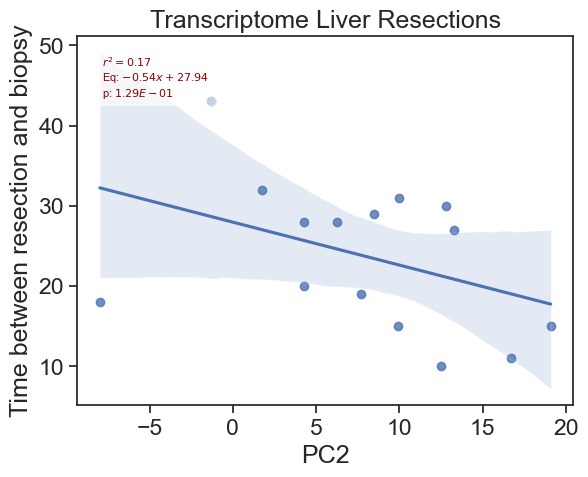

In [55]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Liver Resections')


#plt.savefig('figures/corr_pc2_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Transcriptome Liver Resections')

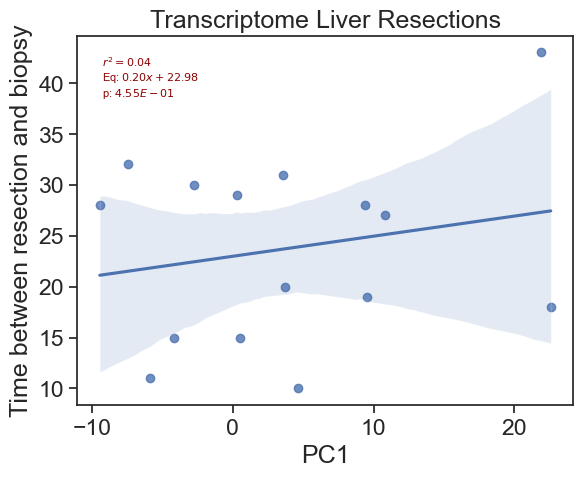

In [56]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Liver Resections')


#plt.savefig('figures/corr_pc1_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Transcriptome Liver Resections')

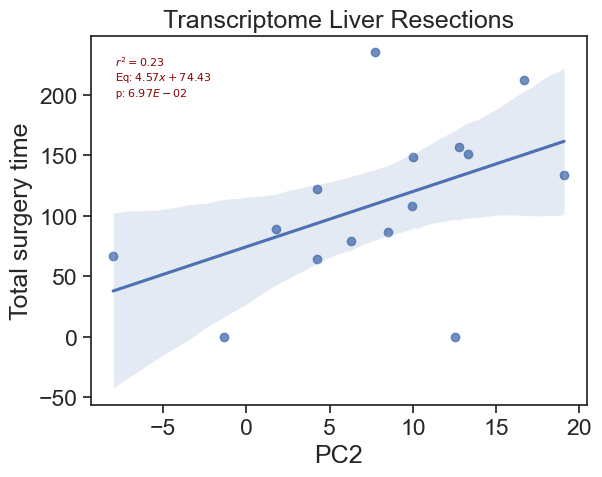

In [57]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Liver Resections')

#plt.savefig('figures/corr_pc2_time_surgery.pdf', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Transcriptome Liver Resections')

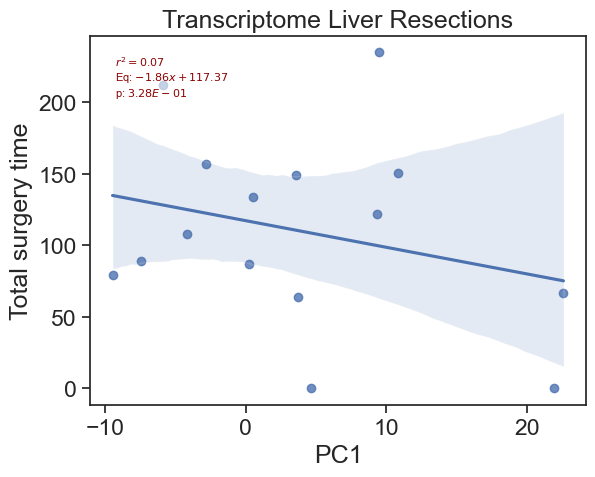

In [58]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Liver Resections')

#plt.savefig('figures/corr_pc1_time_surgery.pdf', dpi=300, bbox_inches='tight')

## 14. Non-tumor paired PCA distances

Quantify within-patient biopsy/resection displacement in PCA space and benchmark it against between-patient distances.

In [60]:
def paired_distance_magnitude(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Calculates paired biopsy-to-resection distances and patient centroids
    in PCA space.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    pair_rows = []
    centroid_rows = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        b_vec = scores.loc[b, pc_cols].values.astype(float)
        r_vec = scores.loc[r, pc_cols].values.astype(float)

        diff = r_vec - b_vec
        dist = np.linalg.norm(diff)

        centroid = (b_vec + r_vec) / 2

        row = {
            patient_col: patient,
            "biopsy_sample": b,
            "resection_sample": r,
            "n_pcs": len(pc_cols),
            "paired_distance": dist,
        }

        for pc, value in zip(pc_cols, diff):
            row[f"{pc}_resection_minus_biopsy"] = value

        pair_rows.append(row)

        centroid_rows.append(
            pd.Series(centroid, index=pc_cols, name=patient)
        )

    paired_distances = pd.DataFrame(pair_rows)
    patient_centroids = pd.DataFrame(centroid_rows)

    return paired_distances, patient_centroids

In [61]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=df_pca,
    meta=metadata_liver,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)


diff_cols = [f"{pc}_resection_minus_biopsy" for pc in pc_cols]

diff_matrix = paired_distances[diff_cols].values

mean_displacement_vector = diff_matrix.mean(axis=0)

mean_vector_length = np.linalg.norm(mean_displacement_vector)
mean_individual_distance = np.mean(
    np.linalg.norm(diff_matrix, axis=1)
)

directional_coherence = mean_vector_length / mean_individual_distance

direction_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "mean_vector_length": [mean_vector_length],
    "mean_individual_paired_distance": [mean_individual_distance],
    "directional_coherence": [directional_coherence],
})



In [62]:
patient_col = 'patient_id'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

# Summary stats for paired distances
paired_median = plot_df[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

In [63]:
plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [64]:
plot_df_norm.mean(numeric_only=True)

paired_distance      21.327862
relative_distance     0.888237
dtype: float64

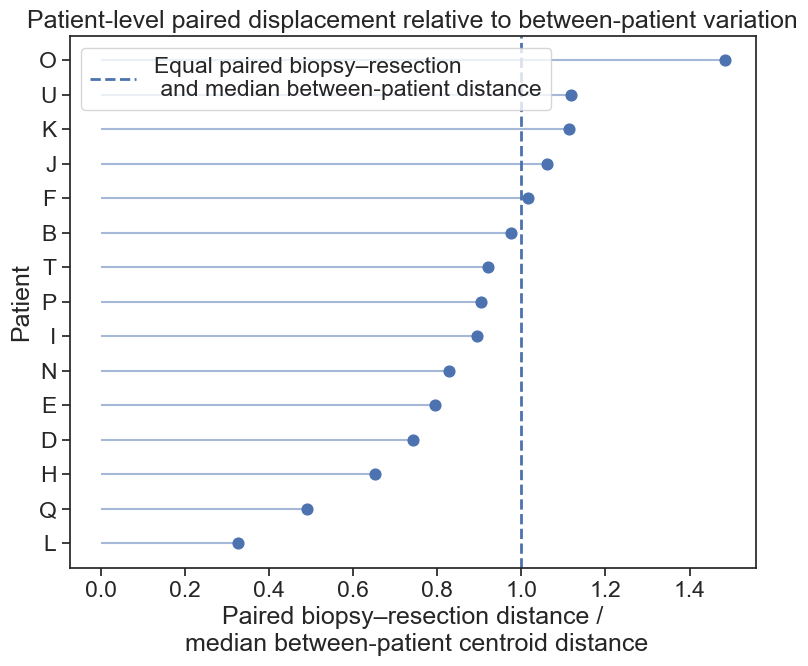

In [65]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

# Summary stats for paired distances
paired_median = plot_df_norm[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")

plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig('Distance_transcriptomics_liver.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
metadata_liver.tail()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,Time between resection and biopsy,Total surgery time,necrosis,nontumor,stroma,tumor,total
Seq_id,,,,,,,,,,,,,
BSSE_QGF_182100,Resection,M,78.0,non-tumor,BSSE_QGF_182100,O,28.0,79.0,1.0,0.0,5.0,94.0,100.0
BSSE_QGF_129482,Resection,M,74.0,non-tumor,BSSE_QGF_129482,P,10.0,NaN,43.0,0.0,15.0,42.0,100.0
BSSE_QGF_182102,Resection,F,70.0,non-tumor,BSSE_QGF_182102,Q,32.0,89.0,0.0,0.0,26.0,74.0,100.0
BSSE_QGF_182104,Resection,M,69.0,non-tumor,BSSE_QGF_182104,T,19.0,235.0,0.0,0.0,0.0,100.0,100.0
BSSE_QGF_182110,Resection,M,81.0,non-tumor,BSSE_QGF_182110,U,15.0,134.0,4.0,0.0,2.0,94.0,100.0


In [67]:
2**14

16384

## 15. Non-tumor patient-blocked permutation test

Enumerate within-patient label swaps to test the multivariate collection-method effect.

In [68]:
def exhaustive_patient_blocked_collection_test(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Exact patient-blocked permutation test for paired Biopsy/Resection PCA scores.
    Enumerates all 2^n within-patient label swaps.

    Suitable when n_pairs is modest, e.g. <= 20.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    keep_samples = []
    patients_ordered = []

    for patient, m in meta.groupby(patient_col):
        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) == 1 and len(resection_samples) == 1:
            keep_samples.extend([biopsy_samples[0], resection_samples[0]])
            patients_ordered.append(patient)

    meta = meta.loc[keep_samples].copy()
    Y = scores.loc[keep_samples, pc_cols].values

    patient_dummies = pd.get_dummies(meta[patient_col], drop_first=False)
    X_patient = patient_dummies.values.astype(float)

    collection_observed = (
        meta[sample_type_col].values == resection_label
    ).astype(float).reshape(-1, 1)

    def rss_multivariate_lm(Y, X):
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        resid = Y - X @ beta
        rss = np.sum(resid ** 2)
        rank = np.linalg.matrix_rank(X)
        df_resid = Y.shape[0] - rank
        return rss, df_resid, rank

    rss_patient, df_patient, rank_patient = rss_multivariate_lm(Y, X_patient)

    X_full_observed = np.column_stack([X_patient, collection_observed])
    rss_full_obs, df_full, rank_full = rss_multivariate_lm(Y, X_full_observed)

    ss_collection_obs = rss_patient - rss_full_obs
    partial_R2_obs = ss_collection_obs / rss_patient

    n_pairs = len(patients_ordered)

    perm_R2 = []

    # Precompute sample indices for each patient
    patient_to_indices = {
        patient: np.where(meta[patient_col].values == patient)[0]
        for patient in patients_ordered
    }

    for swap_pattern in itertools.product([0, 1], repeat=n_pairs):

        collection_perm = collection_observed.copy()

        for patient, swap in zip(patients_ordered, swap_pattern):
            if swap == 1:
                idx = patient_to_indices[patient]
                collection_perm[idx] = 1 - collection_perm[idx]

        X_perm = np.column_stack([X_patient, collection_perm])
        rss_perm_full, _, _ = rss_multivariate_lm(Y, X_perm)

        ss_perm_collection = rss_patient - rss_perm_full
        perm_R2.append(ss_perm_collection / rss_patient)

    perm_R2 = np.array(perm_R2)

    exact_p = np.mean(perm_R2 >= partial_R2_obs - 1e-12)

    result = {
        "n_pairs": n_pairs,
        "n_samples": meta.shape[0],
        "n_pcs": len(pc_cols),
        "observed_partial_R2": partial_R2_obs,
        "observed_partial_R2_percent": 100 * partial_R2_obs,
        "exact_permutation_p_value": exact_p,
        "n_total_permutations": len(perm_R2),
        "n_permutations_ge_observed": int(np.sum(perm_R2 >= partial_R2_obs - 1e-12)),
        "max_permuted_partial_R2": np.max(perm_R2),
        "max_permuted_partial_R2_percent": 100 * np.max(perm_R2),
    }

    return result, perm_R2

In [69]:
joint_test_result, perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=df_pca,
    meta=metadata_liver,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

In [70]:
test_out = pd.DataFrame().from_dict(joint_test_result, orient='index')
test_out.to_csv('Permutation_transcriptome_liver.csv')
test_out

,0
n_pairs,15.000000
n_samples,30.000000
n_pcs,10.000000
observed_partial_R2,0.632532
observed_partial_R2_percent,63.253169
exact_permutation_p_value,0.000061
n_total_permutations,32768.000000
n_permutations_ge_observed,2.000000
max_permuted_partial_R2,0.632532
max_permuted_partial_R2_percent,63.253169


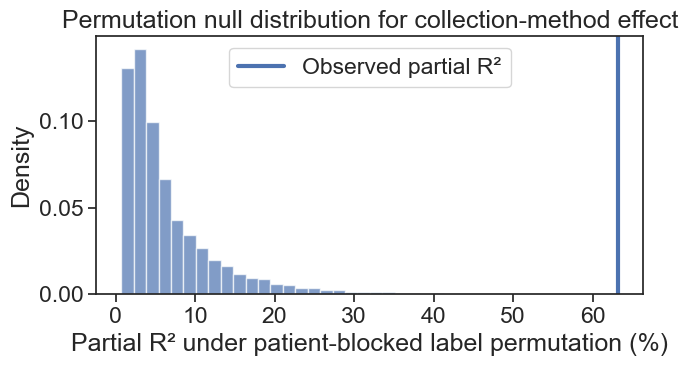

In [71]:
#observed_F = joint_test_result["F"]
observed_partial_R2 = joint_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig('Permutation_histogram_transcriptomics_liver.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 16. Non-tumor differential expression

Fit the paired PyDESeq2 model, summarize results, annotate gene symbols, and prepare volcano-style outputs.

In [83]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.06 seconds.

Fitting dispersions...
... done in 15.19 seconds.



In [84]:
dds.deseq2(fit_type='parametric')

Using parametric fit type.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.06 seconds.

Fitting dispersions...
... done in 15.60 seconds.

Fitting dispersion trend curve...
... done in 1.62 seconds.

Fitting MAP dispersions...
... done in 17.40 seconds.

Fitting LFCs...
... done in 14.45 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 0 outlier genes.



In [85]:
# cooksCutoff=FALSE, independentFiltering=FALSE
ds = DeseqStats(dds, contrast=['Sample_type', 'Resection', 'Biopsy'],
                cooks_filter=False, independent_filter=False)

In [86]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Sample_type Resection vs Biopsy
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000160072  162.728593        0.093542  0.122348  0.764555  0.444537   
ENSG00000142611   11.950306        0.200011  0.367767  0.543853  0.586543   
ENSG00000157911  163.122437       -0.591115  0.153434 -3.852556  0.000117   
ENSG00000142655  325.321262       -0.268617  0.106888 -2.513078  0.011968   
ENSG00000149527   53.267901       -0.497611  0.241018 -2.064627  0.038958   
...                     ...             ...       ...       ...       ...   
ENSG00000278817   20.231819       -0.137893  0.265095 -0.520166  0.602948   
ENSG00000278384   19.664147       -1.035157  0.318826 -3.246780  0.001167   
ENSG00000275063   21.311922       -0.585953  0.269888 -2.171097  0.029924   
ENSG00000277856   26.629178       -0.174572  0.260247 -0.670793  0.502352   
ENSG00000271254  105.915290       -0.294578  0.192342 -1.531535  0.125637   

     

... done in 12.50 seconds.



In [87]:
df_res_liver = ds.results_df
df_res_liver['abs_diff'] = df_res_liver.log2FoldChange.abs()
df_res_liver = df_res_liver.sort_values('abs_diff', ascending=False)
df_res_liver.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff
ENSG00000125740,840.911837,9.166114,0.473588,19.354625,1.863440e-83,7.324715e-80,9.166114
ENSG00000170345,5716.198043,5.955480,0.381263,15.620413,5.286235e-55,1.038943e-51,5.955480
ENSG00000109321,32.868382,5.730060,0.728721,7.863170,3.745326e-15,4.749013e-13,5.730060
ENSG00000123358,311.474553,5.151057,0.333869,15.428389,1.054699e-53,1.842558e-50,5.151057
ENSG00000146678,14639.041145,4.723085,0.435767,10.838551,2.260234e-27,1.064461e-24,4.723085


In [88]:
# Add Gene Names
with open('../../../ensemble_mappings_gene.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_n_l = df_res_liver.reset_index(names='Geneid').copy()
    
df_n_l['Gene'] = df_n_l['Geneid'].map(loaded_dict)
df_n_l.Gene = df_n_l.Gene.replace('', np.nan)
df_n_l['Gene'] = np.where(df_n_l.Gene.isnull(), df_n_l.Geneid, df_n_l.Gene)
df_n_l.index = df_n_l.Geneid
df_n_l = df_n_l.drop('Geneid', axis=1)

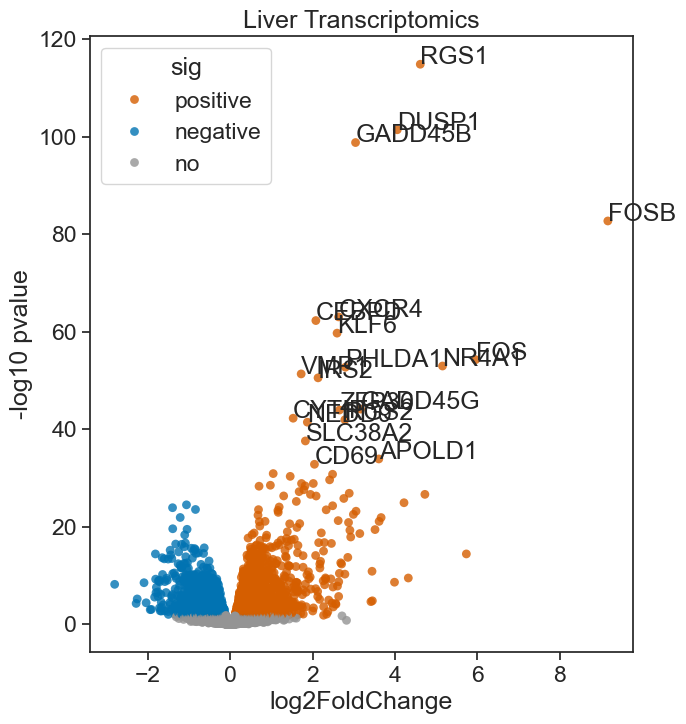

<Figure size 640x480 with 0 Axes>

In [89]:
df_ttest_ = df_n_l.copy()

# Drop non-significant outlier
#df_ttest_ = df_ttest_[df_ttest_.Gene != 'SERPINB7']

df_ttest_['sig'] = np.where((df_ttest_['padj'] < 0.05) &\
                            (df_ttest_['log2FoldChange'] > 0), 'positive',
                    np.where((df_ttest_['padj'] < 0.05) &\
                             (df_ttest_['log2FoldChange'] < 0), 'negative', 
                                    'no'))
df_ttest_['-log10 pvalue'] = -np.log10(df_ttest_.pvalue)

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='log2FoldChange', y='-log10 pvalue',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pvalue', ascending=False)
                
most_sig['Gene'] = most_sig.index.map(loaded_dict)

for i in range(0,20):
    x = most_sig.iloc[i,:]['log2FoldChange'].item()
    y = most_sig.iloc[i,:]['-log10 pvalue'].item() + 0.05
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('Liver Transcriptomics')
plt.show()
plt.savefig('figures/Volcano_rnaseq_liver_output.pdf', bbox_inches='tight', dpi=300)

In [90]:
df_ttest_liver = df_ttest_.copy()

Text(0.5, 1.0, 'FOSB')

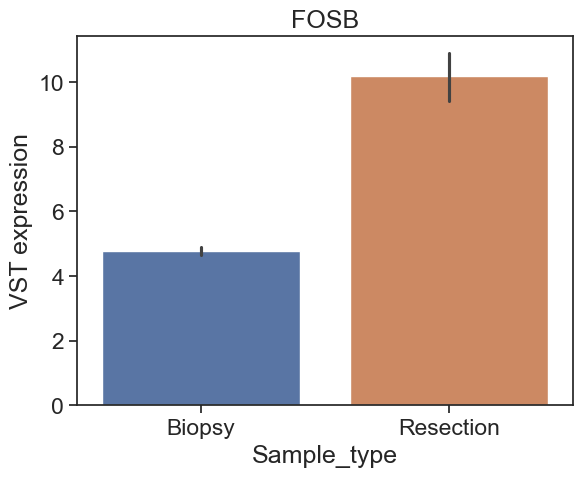

In [91]:
test_direction = pd.concat([df_liver.loc['ENSG00000125740',:], metadata_liver.Sample_type], axis=1)

sns.barplot(test_direction, x='Sample_type', y='ENSG00000125740', hue='Sample_type', hue_order=hue_order)
plt.ylabel('VST expression')
plt.title('FOSB')


In [92]:
df_ttest_.sort_values('abs_diff', ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue
Geneid,,,,,,,,,,
ENSG00000125740,840.911837,9.166114,0.473588,19.354625,1.863440e-83,7.324715e-80,9.166114,FOSB,positive,82.729685
ENSG00000170345,5716.198043,5.955480,0.381263,15.620413,5.286235e-55,1.038943e-51,5.955480,FOS,positive,54.276854
ENSG00000109321,32.868382,5.730060,0.728721,7.863170,3.745326e-15,4.749013e-13,5.730060,AREG,positive,14.426510
ENSG00000123358,311.474553,5.151057,0.333869,15.428389,1.054699e-53,1.842558e-50,5.151057,NR4A1,positive,52.976872
ENSG00000146678,14639.041145,4.723085,0.435767,10.838551,2.260234e-27,1.064461e-24,4.723085,IGFBP1,positive,26.645847
...,...,...,...,...,...,...,...,...,...,...
ENSG00000128536,169.775371,0.000110,0.131425,0.000840,9.993300e-01,9.996143e-01,0.000110,CDHR3,no,0.000291
ENSG00000189180,2151.645997,0.000102,0.057858,0.001755,9.986001e-01,9.991720e-01,0.000102,ZNF33A,no,0.000608
ENSG00000162734,942.679745,0.000074,0.091786,0.000802,9.993600e-01,9.996143e-01,0.000074,PEA15,no,0.000278


In [93]:
df_sig_l = df_ttest_[df_ttest_.padj < 0.05].copy()

## 17. Non-tumor pathway enrichment and export

Use significant genes and the tested background for Hallmark enrichment, then export expression and statistics.

In [94]:
msig = Msigdb()
gmt = msig.get_gmt(category='h.all', dbver="2024.1.Hs")

In [95]:
# Define background set as all identified protein codeing genes
bg_genes = set(df_n_l['Gene'])
len(bg_genes)

15722

In [96]:
enr_res = gp.enrichr(gene_list=df_sig_l.Gene.tolist(),
 gene_sets=gmt,
 organism='Homo Sapiens',
 outdir='HM/',
 background=bg_genes,
 )

In [97]:
enr_res.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,gs_ind_0,HALLMARK_ADIPOGENESIS,76/194,5.964914e-03,2.294198e-02,1.478157,7.570913,TALDO1;ECHS1;CS;REEP6;TKT;PPP1R15B;GPD2;CAVIN2...
1,gs_ind_0,HALLMARK_ALLOGRAFT_REJECTION,64/187,1.512662e-01,2.521104e-01,1.192248,2.251815,NLRP3;CD2;DYRK3;IL1B;EREG;HCLS1;CD86;SRGN;IRF8...
2,gs_ind_0,HALLMARK_ANDROGEN_RESPONSE,45/97,6.995324e-04,4.372077e-03,1.983493,14.410272,AKAP12;PGM3;PIAS1;UAP1;SAT1;DNAJB9;PTK2B;XRCC6...
3,gs_ind_0,HALLMARK_ANGIOGENESIS,15/34,6.497191e-02,1.412433e-01,1.813252,4.957069,VCAN;FSTL1;TNFRSF21;VAV2;THBD;LPL;KCNJ8;FGFR1;...
4,gs_ind_0,HALLMARK_APICAL_JUNCTION,54/180,5.868579e-01,7.335724e-01,0.981166,0.522935,CD99;LAMB3;SRC;PIK3CB;PCDH1;HRAS;COL17A1;PALS1...
5,gs_ind_0,HALLMARK_APICAL_SURFACE,20/41,1.064205e-02,3.325642e-02,2.176964,9.889820,SCUBE1;PLAUR;EPHB4;RTN4RL1;RHCG;BRCA1;THY1;EFN...
6,gs_ind_0,HALLMARK_APOPTOSIS,73/157,1.697969e-05,1.697969e-04,1.996623,21.929898,CD2;IL1B;CD69;ADD1;BTG2;BTG3;EREG;CD44;PPP3R1;...
7,gs_ind_0,HALLMARK_BILE_ACID_METABOLISM,43/110,3.352596e-02,7.982373e-02,1.472251,4.998932,CYP7B1;PEX16;NR0B2;LONP2;TTR;RXRA;PEX11G;BCAR3...
8,gs_ind_0,HALLMARK_CHOLESTEROL_HOMEOSTASIS,37/74,3.418858e-04,2.442041e-03,2.287950,18.260210,TRIB3;LSS;PLAUR;CYP51A1;PCYT2;GLDC;LDLR;NFIL3;...
9,gs_ind_0,HALLMARK_COAGULATION,29/131,9.874611e-01,9.874611e-01,0.653454,0.008245,APOC3;F8;C8G;DUSP6;BMP1;TIMP3;GP1BA;ARF4;KLF7;...


C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\3009313408.py:9: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)',


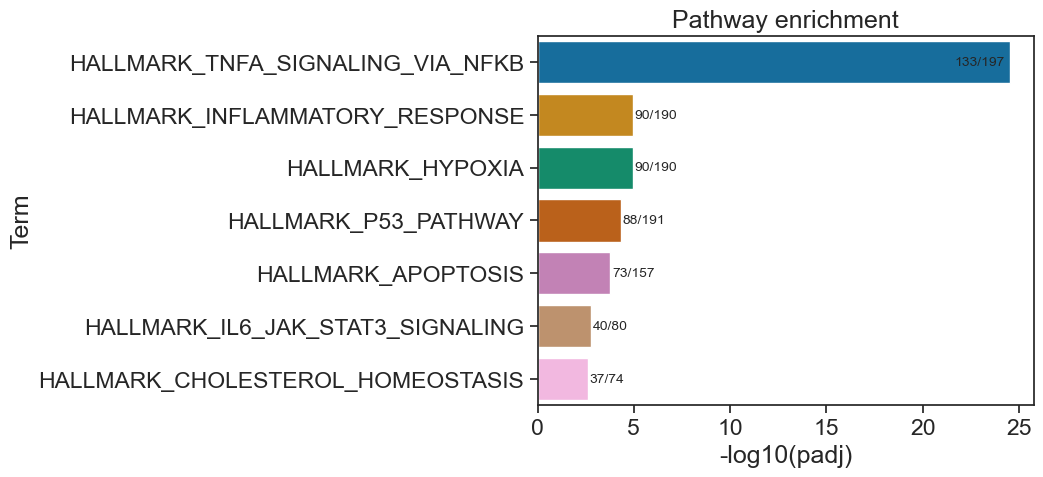

In [98]:
path_res = enr_res.results
path_res = path_res.sort_values('Adjusted P-value').reset_index(drop=True)

path_res['count'] = path_res.Overlap.str.split('/').str[0].astype(int) / path_res.Overlap.str.split('/').str[1].astype(int)
path_res['-log10(padj)'] = -np.log10(path_res['Adjusted P-value'])
path_res_sig = path_res[path_res['P-value'] < 0.05]

# Barplot
g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)', 
                   palette=sns.color_palette('colorblind'), orient='h')

# Annotate bars with Overlap values
for i, (bar, overlap) in enumerate(zip(g.patches, path_res_sig.iloc[:7]['Overlap'])):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if i == 0:
        width = width - 3
    g.text(width + 0.1, y, overlap, va='center', ha='left', fontsize=10)

plt.title('Pathway enrichment')
#plt.savefig(f'figures/HM_liver_rna_pathway_enrichment.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [99]:
# Extract genes in each pathway
pathway_genes = {}
for row in path_res_sig.iterrows():
    genes = set(row[1]['Genes'].split(';'))
    path = row[1]['Term']
    pathway_genes[path] = genes

Text(0.5, 0, 'log2FoldChange')

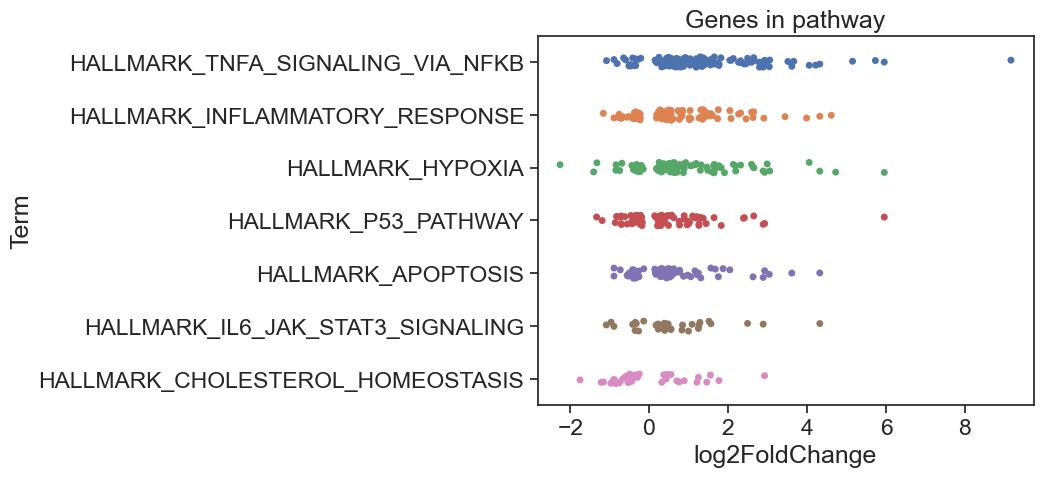

In [101]:
# Plot fold-change of genes identified in pathway enrichment

genes_list = []
for i in range(0,7):
    path = path_res_sig.Term[i]
    genes = pathway_genes[path]

    gene_data = df_sig_l[df_sig_l.Gene.isin(genes)].log2FoldChange
    genes_list.append(gene_data)
    
df_path_genes = pd.concat(genes_list, axis=1)
df_path_genes.columns = path_res_sig.Term[0:7]
df_path_genes.head()

sns.stripplot(data=df_path_genes, orient='h')
plt.title('Genes in pathway')
plt.xlabel('log2FoldChange')
#plt.savefig(f'figures/HM_liver_rna_pathway_FC.pdf', bbox_inches='tight', dpi=300)

In [102]:
df_path_genes.head()

Term,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_INFLAMMATORY_RESPONSE,HALLMARK_HYPOXIA,HALLMARK_P53_PATHWAY,HALLMARK_APOPTOSIS,HALLMARK_IL6_JAK_STAT3_SIGNALING,HALLMARK_CHOLESTEROL_HOMEOSTASIS
Geneid,,,,,,,
ENSG00000125740,9.166114,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000170345,5.955480,NaN,5.955480,5.95548,NaN,NaN,NaN
ENSG00000109321,5.730060,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000123358,5.151057,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000136244,4.320137,4.320137,4.320137,NaN,4.320137,4.320137,NaN


In [103]:
df_path_genes.isna()

Term,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_INFLAMMATORY_RESPONSE,HALLMARK_HYPOXIA,HALLMARK_P53_PATHWAY,HALLMARK_APOPTOSIS,HALLMARK_IL6_JAK_STAT3_SIGNALING,HALLMARK_CHOLESTEROL_HOMEOSTASIS
Geneid,,,,,,,
ENSG00000125740,False,True,True,True,True,True,True
ENSG00000170345,False,True,False,False,True,True,True
ENSG00000109321,False,True,True,True,True,True,True
ENSG00000123358,False,True,True,True,True,True,True
ENSG00000136244,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...
ENSG00000137449,True,True,True,True,True,True,False
ENSG00000104823,True,True,True,True,True,True,False
ENSG00000164211,True,True,True,True,True,True,False


In [104]:
# Create output csv file

# Populate export table with pathway gene identity

hm_dict = {}

for row in path_res.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in hm_dict.keys():
            prev_term = hm_dict[gene]
            prev_term.append(term)
            hm_dict[gene] = prev_term
        else:
            hm_dict[gene] = [term]
            
df_ttest_['Hallmark'] = df_ttest_.Gene.map(hm_dict)
df_ttest_.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
Geneid,,,,,,,,,,,
ENSG00000125740,840.911837,9.166114,0.473588,19.354625,1.863440e-83,7.324715e-80,9.166114,FOSB,positive,82.729685,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_UV..."
ENSG00000170345,5716.198043,5.955480,0.381263,15.620413,5.286235e-55,1.038943e-51,5.955480,FOS,positive,54.276854,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_HY..."
ENSG00000109321,32.868382,5.730060,0.728721,7.863170,3.745326e-15,4.749013e-13,5.730060,AREG,positive,14.426510,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_ES..."
ENSG00000123358,311.474553,5.151057,0.333869,15.428389,1.054699e-53,1.842558e-50,5.151057,NR4A1,positive,52.976872,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_UV..."
ENSG00000146678,14639.041145,4.723085,0.435767,10.838551,2.260234e-27,1.064461e-24,4.723085,IGFBP1,positive,26.645847,"[HALLMARK_HYPOXIA, HALLMARK_XENOBIOTIC_METABOL..."


In [105]:
df_liver_out = pd.concat([df_liver, df_ttest_], axis=1)
df_liver_out.head()

,BSSE_QGF_129466,BSSE_QGF_182052,BSSE_QGF_145476,BSSE_QGF_145472,BSSE_QGF_129476,BSSE_QGF_182072,BSSE_QGF_182064,BSSE_QGF_129474,BSSE_QGF_145460,BSSE_QGF_182054,...,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
ENSG00000160072,7.628677,7.220001,7.157348,7.057075,7.795695,7.794800,7.907571,7.261420,7.747785,7.717703,...,0.093542,0.122348,0.764555,0.444537,0.598294,0.093542,ATAD3B,no,0.352093,NaN
ENSG00000142611,5.768085,5.059225,4.347859,5.092045,6.565460,4.967678,4.640026,5.477991,6.177095,4.643611,...,0.200011,0.367767,0.543853,0.586543,0.720487,0.200011,PRDM16,no,0.231700,NaN
ENSG00000157911,7.655978,7.186387,7.603541,8.785904,7.243597,8.304344,8.260630,7.970926,7.619202,8.255398,...,-0.591115,0.153434,-3.852556,0.000117,0.001011,0.591115,PEX10,negative,3.932218,NaN
ENSG00000142655,8.628060,8.388120,8.684634,9.166289,8.352413,8.970732,8.782465,8.872192,8.429772,8.515360,...,-0.268617,0.106888,-2.513078,0.011968,0.041285,0.268617,PEX14,negative,1.921968,"[HALLMARK_UV_RESPONSE_DN, HALLMARK_ADIPOGENESI..."
ENSG00000149527,6.847492,5.647802,5.967643,5.704994,6.369002,6.500375,7.658777,7.456830,6.308577,5.770824,...,-0.497611,0.241018,-2.064627,0.038958,0.102569,0.497611,PLCH2,no,1.409400,NaN


In [106]:
df_liver_out.to_csv('RNA_liver_output_29072026.csv')

# Part II — HCC tumor

Repeat the paired workflow within tumor tissue.

In [107]:
metadata_hcc.columns

Index(['Sample_type', 'Sex', 'Age', 'Tissue', 'Seq_id', 'patient_id',
       'Time between resection and biopsy', 'Total surgery time', 'necrosis',
       'nontumor', 'stroma', 'tumor', 'total'],
      dtype='object')

In [108]:
df_pc_hcc = df_pc.loc[:,metadata_hcc.index].copy()

## 18. HCC filtering and VST

Filter genes in the tumor subset and calculate variance-stabilized expression values.

In [109]:
# Filtering

# Create a copy to work on
df_pc_hcc_f = df_pc_hcc.copy()

# Apply the filter criteria
for col in df_pc_hcc_f.columns:
    df_pc_hcc_f[col] = np.where(df_pc_hcc_f[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_hcc_f['Keep'] = np.where(df_pc_hcc_f.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_hcc_f[df_pc_hcc_f.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_hcc_f = df_pc_hcc.loc[keep_indices_].copy()

In [110]:
df_pc_hcc_f.shape

(16575, 30)

In [111]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_hcc_f.T,
    metadata=metadata_hcc,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~patient_id + Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_hcc_f.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_hcc_f.T.index, columns=df_pc_hcc_f.T.columns
)
df_hcc = transformed_counts.T

Fitting size factors...
... done in 0.06 seconds.

Fitting size factors...
... done in 0.06 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 17.03 seconds.



In [112]:
df_hcc.head()

Seq_id,BSSE_QGF_129467,BSSE_QGF_182053,BSSE_QGF_145477,BSSE_QGF_145473,BSSE_QGF_129477,BSSE_QGF_182073,BSSE_QGF_182065,BSSE_QGF_129475,BSSE_QGF_145461,BSSE_QGF_182055,...,BSSE_QGF_182107,BSSE_QGF_182099,BSSE_QGF_129479,BSSE_QGF_145463,BSSE_QGF_182085,BSSE_QGF_182101,BSSE_QGF_55744,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182111
ENSG00000160072,8.087017,8.342778,9.721116,7.779847,7.964220,9.663918,9.444492,8.597433,8.313341,8.340976,...,9.845260,8.775350,8.280598,8.459959,7.821504,8.640016,8.484763,9.016673,7.743095,8.545999
ENSG00000142611,4.827391,4.810591,5.120588,5.172637,6.405881,5.586655,6.328679,5.301185,5.282743,5.524255,...,4.769393,4.861532,5.273470,4.786215,5.033445,6.483175,7.038581,7.163212,6.550232,4.979339
ENSG00000157911,7.876716,8.027148,8.389657,8.592955,7.096751,7.916985,8.601629,8.308721,8.222739,7.613065,...,7.553239,8.318455,8.243026,7.747719,7.252696,7.842979,7.390491,7.322635,8.407994,7.298453
ENSG00000142655,6.896657,8.729402,8.939685,9.433079,7.987384,9.142334,9.018697,9.000283,9.515011,8.187141,...,8.775230,9.148201,9.157156,9.243759,8.440416,7.251872,8.108142,7.780053,8.853196,6.910852
ENSG00000149527,5.957286,7.187998,9.744854,7.237911,8.518742,7.429149,7.379030,5.759340,6.279460,6.492262,...,7.077454,6.117985,5.027819,7.410964,5.561066,4.750092,5.738697,7.761748,4.990299,5.788127


## 19. HCC PCA and covariate checks

Visualize the leading tumor PCs and examine correlations with clinical timing variables.

In [113]:
df_hcc_pca = df_hcc.copy()
df_hcc_pca['expression_std'] = df_hcc_pca.std(axis=1)
df_hcc_pca = df_hcc_pca.sort_values('expression_std', ascending=False)
df_hcc_pca = df_hcc_pca.iloc[:500,:-1]
df_hcc_pca.head()

Seq_id,BSSE_QGF_129467,BSSE_QGF_182053,BSSE_QGF_145477,BSSE_QGF_145473,BSSE_QGF_129477,BSSE_QGF_182073,BSSE_QGF_182065,BSSE_QGF_129475,BSSE_QGF_145461,BSSE_QGF_182055,...,BSSE_QGF_182107,BSSE_QGF_182099,BSSE_QGF_129479,BSSE_QGF_145463,BSSE_QGF_182085,BSSE_QGF_182101,BSSE_QGF_55744,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182111
ENSG00000160868,9.543428,15.006075,13.393114,14.463017,16.930943,15.729927,11.859455,14.834049,9.940524,13.754529,...,17.127805,15.781195,15.728967,8.400435,9.241555,17.825369,7.310433,14.212548,16.430526,6.455370
ENSG00000147604,6.799071,14.756788,6.866513,6.708476,7.196574,14.242649,14.046246,7.953823,6.971926,13.849950,...,14.598914,14.825129,8.704142,6.903589,14.492379,15.121311,13.769279,15.232200,15.961835,16.416229
ENSG00000132693,17.196730,14.437772,14.662877,17.482184,14.578260,9.245244,15.729062,15.398744,19.283086,9.984118,...,10.818982,16.168434,14.552431,19.195683,12.474163,13.185900,14.947222,16.425957,7.328013,5.676852
ENSG00000177954,6.687564,14.475361,7.862925,7.043691,7.016900,14.387216,13.397591,6.762467,6.853886,13.659166,...,14.801040,13.945850,6.925951,6.469935,14.425402,15.312256,13.352786,14.527184,15.373697,16.176931
ENSG00000130649,11.434553,14.605548,13.568570,15.255284,16.707551,11.862390,10.440927,17.902493,17.295649,14.596475,...,9.580611,13.460495,19.317284,17.080265,15.277007,13.133563,8.100288,14.729117,16.962997,13.913450


In [114]:
# scaled data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_hcc_pca.T)

In [115]:
pca = PCA(n_components=10)

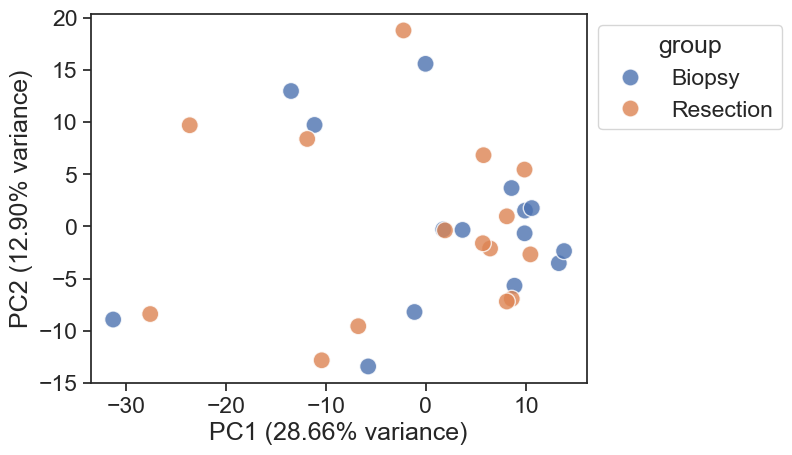

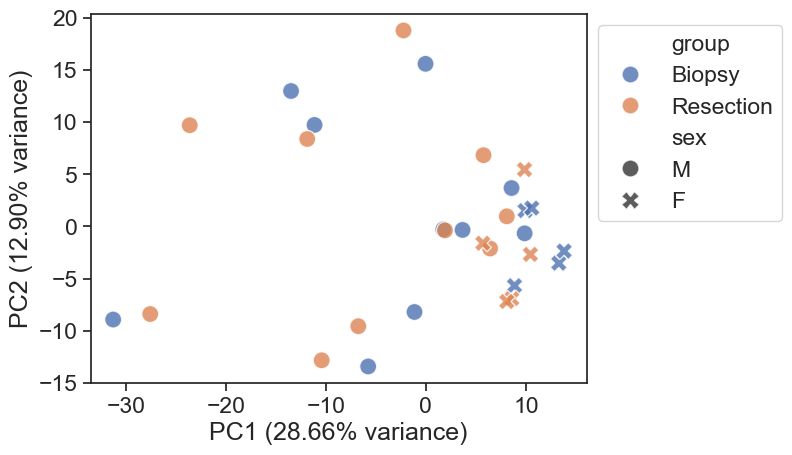

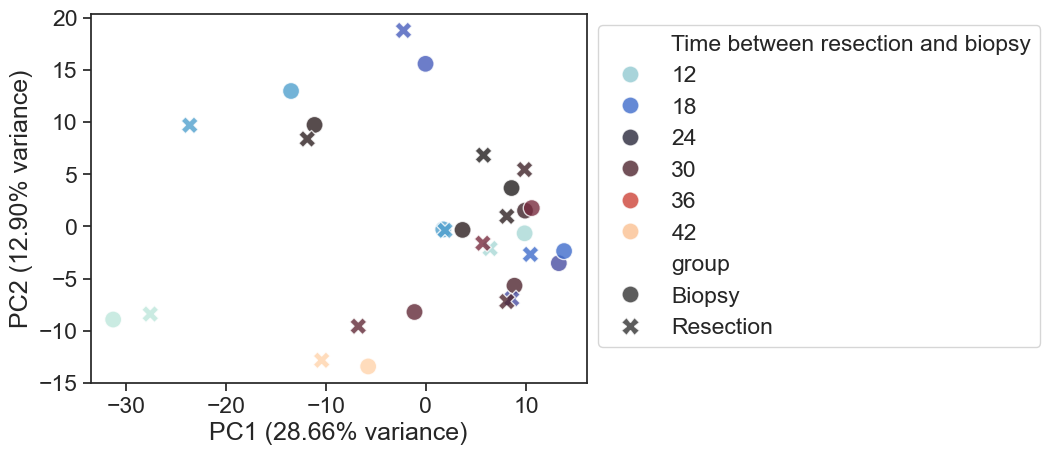

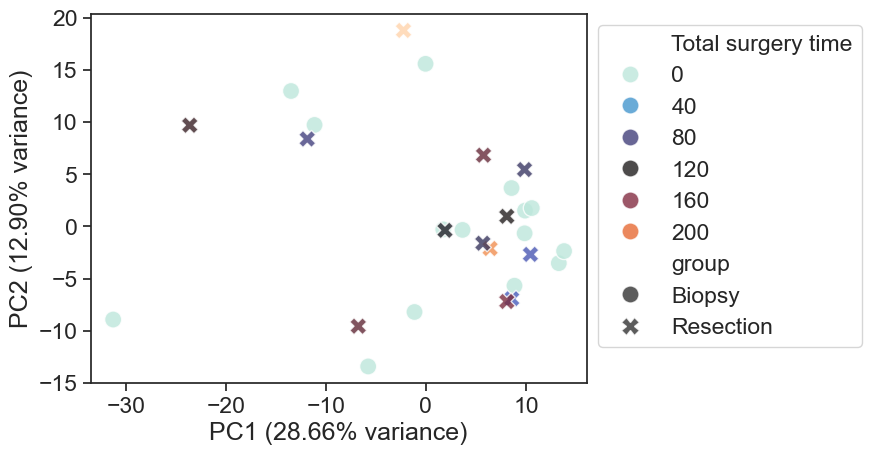

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_22804\664036253.py:57: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


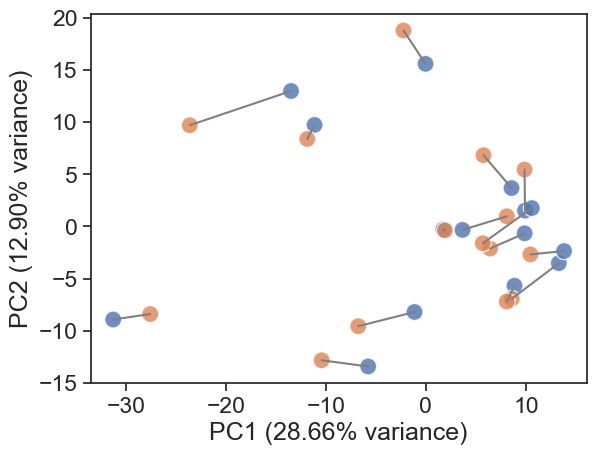

In [116]:
projections = pca.fit_transform(scaled_data)

pc_x = 1
pc_y = 2

df_pca = pd.DataFrame(projections, columns=[f"PC{x}" for x in range(1,11)], index=df_hcc_pca.columns)
df_pca['group'] = metadata_hcc.Sample_type
df_pca['sex'] = metadata_hcc.Sex
df_pca['patient_id'] = metadata_hcc.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_hcc['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_hcc['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y),style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc_sex.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_timeBvR_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y),style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_surgerytime_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
plt.savefig(f'figures/PCA_hcc_pat_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
plt.show()


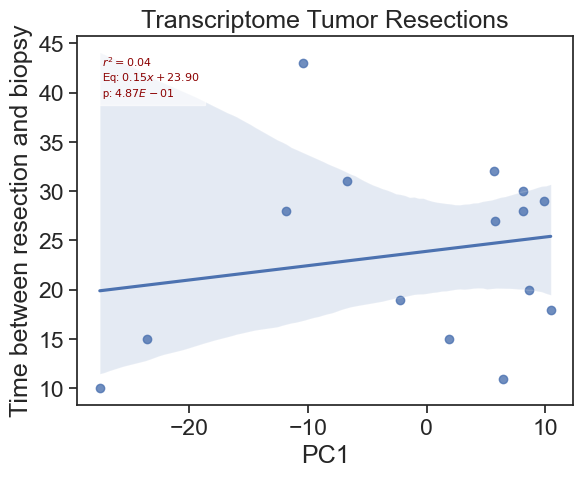

In [117]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Tumor Resections')


plt.savefig('figures/corr_pc1_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

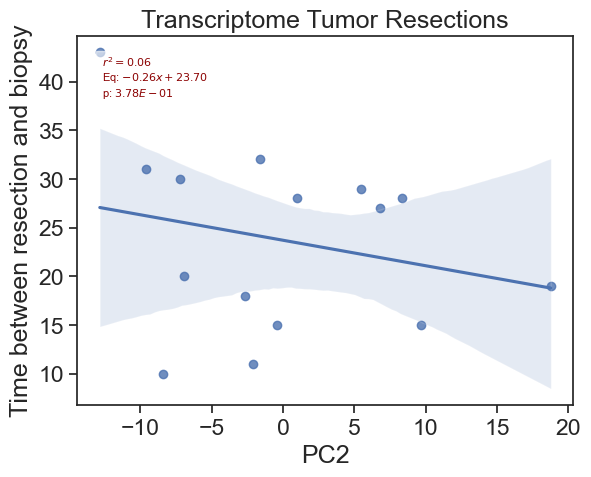

In [118]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Tumor Resections')


plt.savefig('figures/corr_pc2_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

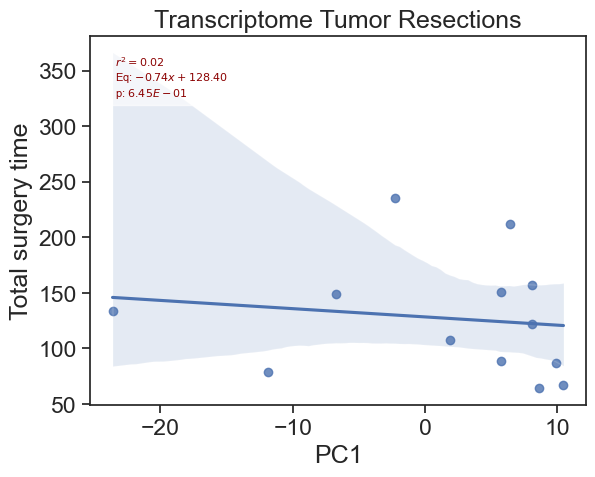

In [119]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Tumor Resections')

plt.savefig('figures/corr_pc1_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

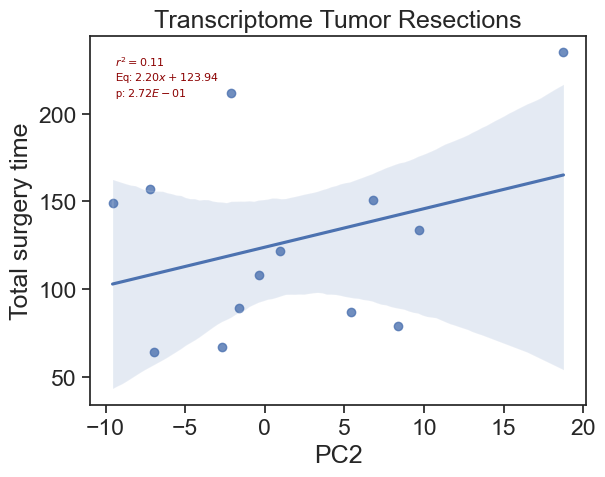

In [120]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Tumor Resections')

plt.savefig('figures/corr_pc2_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

## 20. HCC paired PCA distances

Measure biopsy/resection displacement, relative distance, and the patient-blocked collection-method effect.

In [121]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

# scores,
# meta,
# patient_col="Patient ID",
# sample_type_col="Sample_type",
# biopsy_label="Biopsy",
# resection_label="Resection",

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=df_pca,
    meta=metadata_hcc,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy
0,B,BSSE_QGF_129467,BSSE_QGF_129469,10,6.111473,-4.647659,0.589800,-2.236634,-1.741248,-1.035821,-1.810943,0.625603,-1.221399,0.815689,-0.682673
1,D,BSSE_QGF_182053,BSSE_QGF_182083,10,4.911452,-0.052871,3.929396,-1.019450,2.224871,0.851404,0.739917,-1.073306,-0.317350,0.346819,-0.211500
2,E,BSSE_QGF_145477,BSSE_QGF_145479,10,9.941458,-5.620566,-1.361504,-2.611147,-5.137494,0.378571,-3.756399,1.429253,0.376986,3.647067,1.560886
3,F,BSSE_QGF_145473,BSSE_QGF_145475,10,5.117466,-3.450432,-1.454248,-0.167421,0.927005,-2.014426,-0.089323,0.244715,1.412994,2.079822,-0.912570
4,H,BSSE_QGF_129477,BSSE_QGF_129481,10,11.114294,-4.705566,-3.411290,2.500822,-1.964274,0.738905,-0.871647,-3.819722,-3.169647,4.413897,-5.848984
5,I,BSSE_QGF_182073,BSSE_QGF_182107,10,6.869787,-0.768119,-1.513402,-2.095591,-2.467156,1.543170,-4.853501,-1.741024,-0.750858,0.095858,2.072013
6,J,BSSE_QGF_182065,BSSE_QGF_182099,10,6.368016,4.425951,1.300384,1.784743,-1.238636,1.649279,-2.138692,-1.753766,-0.946701,-0.492377,-1.744581
7,K,BSSE_QGF_129475,BSSE_QGF_129479,10,15.492196,-2.801890,3.146266,-7.986659,-8.106303,-0.507189,-8.873012,-3.124723,-1.759176,0.734447,-0.611623
8,L,BSSE_QGF_145461,BSSE_QGF_145463,10,4.088739,-3.365993,-0.319533,1.583156,1.488908,-0.374208,0.518370,0.138413,-0.055223,0.279090,-0.231756
9,N,BSSE_QGF_182055,BSSE_QGF_182085,10,5.460893,0.170154,-0.088515,-1.290212,-4.060924,1.028058,-1.317047,2.649422,-0.162530,1.007490,0.881142


In [122]:
between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

magnitude_summary

,n_pairs,n_pcs,median_paired_distance,mean_paired_distance,median_between_patient_centroid_distance,paired_to_between_patient_distance_ratio,median_paired_distance_percentile_vs_between_patient
0,15,10,6.368016,8.079755,28.87176,0.220562,0.0


In [123]:
paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy,percentile_vs_between_patient_centroids,ratio_to_median_between_patient_distance
0,B,BSSE_QGF_129467,BSSE_QGF_129469,10,6.111473,-4.647659,0.589800,-2.236634,-1.741248,-1.035821,-1.810943,0.625603,-1.221399,0.815689,-0.682673,0.000000,0.211676
1,D,BSSE_QGF_182053,BSSE_QGF_182083,10,4.911452,-0.052871,3.929396,-1.019450,2.224871,0.851404,0.739917,-1.073306,-0.317350,0.346819,-0.211500,0.000000,0.170113
2,E,BSSE_QGF_145477,BSSE_QGF_145479,10,9.941458,-5.620566,-1.361504,-2.611147,-5.137494,0.378571,-3.756399,1.429253,0.376986,3.647067,1.560886,0.000000,0.344332
3,F,BSSE_QGF_145473,BSSE_QGF_145475,10,5.117466,-3.450432,-1.454248,-0.167421,0.927005,-2.014426,-0.089323,0.244715,1.412994,2.079822,-0.912570,0.000000,0.177248
4,H,BSSE_QGF_129477,BSSE_QGF_129481,10,11.114294,-4.705566,-3.411290,2.500822,-1.964274,0.738905,-0.871647,-3.819722,-3.169647,4.413897,-5.848984,0.000000,0.384954
5,I,BSSE_QGF_182073,BSSE_QGF_182107,10,6.869787,-0.768119,-1.513402,-2.095591,-2.467156,1.543170,-4.853501,-1.741024,-0.750858,0.095858,2.072013,0.000000,0.237941
6,J,BSSE_QGF_182065,BSSE_QGF_182099,10,6.368016,4.425951,1.300384,1.784743,-1.238636,1.649279,-2.138692,-1.753766,-0.946701,-0.492377,-1.744581,0.000000,0.220562
7,K,BSSE_QGF_129475,BSSE_QGF_129479,10,15.492196,-2.801890,3.146266,-7.986659,-8.106303,-0.507189,-8.873012,-3.124723,-1.759176,0.734447,-0.611623,3.809524,0.536586
8,L,BSSE_QGF_145461,BSSE_QGF_145463,10,4.088739,-3.365993,-0.319533,1.583156,1.488908,-0.374208,0.518370,0.138413,-0.055223,0.279090,-0.231756,0.000000,0.141617
9,N,BSSE_QGF_182055,BSSE_QGF_182085,10,5.460893,0.170154,-0.088515,-1.290212,-4.060924,1.028058,-1.317047,2.649422,-0.162530,1.007490,0.881142,0.000000,0.189143


In [124]:
diff_cols = [f"{pc}_resection_minus_biopsy" for pc in pc_cols]

diff_matrix = paired_distances[diff_cols].values

mean_displacement_vector = diff_matrix.mean(axis=0)

mean_vector_length = np.linalg.norm(mean_displacement_vector)
mean_individual_distance = np.mean(
    np.linalg.norm(diff_matrix, axis=1)
)

directional_coherence = mean_vector_length / mean_individual_distance

direction_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "mean_vector_length": [mean_vector_length],
    "mean_individual_paired_distance": [mean_individual_distance],
    "directional_coherence": [directional_coherence],
})

direction_summary

,n_pairs,n_pcs,mean_vector_length,mean_individual_paired_distance,directional_coherence
0,15,10,3.974457,8.079755,0.491903


In [125]:
patient_col = 'patient_id'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [126]:
plot_df_norm.mean(numeric_only=True)

paired_distance      8.079755
relative_distance    0.336496
dtype: float64

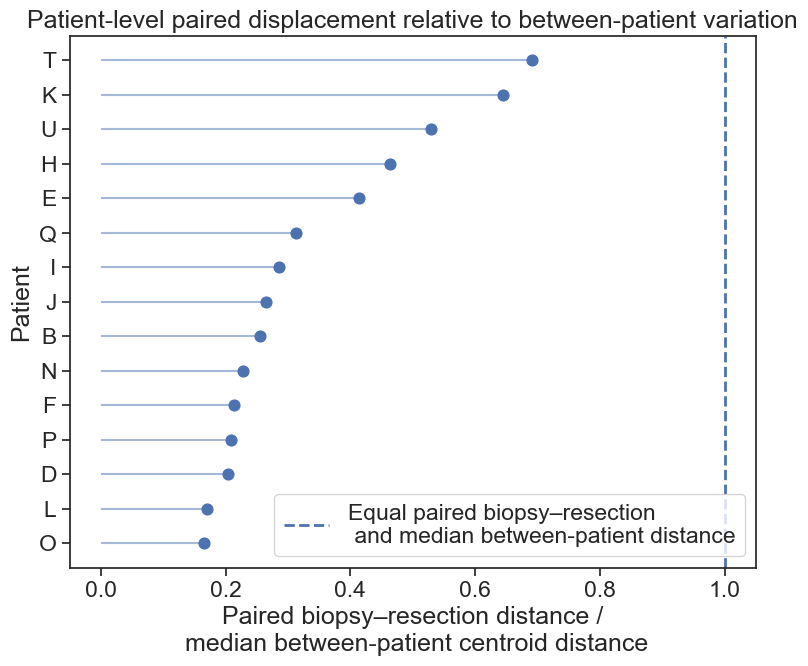

In [127]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")
#plt.axvline(0.5, linestyle=":", linewidth=1.5)
#plt.axvline(0.25, linestyle=":", linewidth=1.5)


plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig('Distances_transcriptomics_hcc.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [128]:
joint_test_result, perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=df_pca,
    meta=metadata_hcc,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

joint_test_result

{'n_pairs': 15,
 'n_samples': 30,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.194708600473651),
 'observed_partial_R2_percent': np.float64(19.4708600473651),
 'exact_permutation_p_value': np.float64(0.00830078125),
 'n_total_permutations': 32768,
 'n_permutations_ge_observed': 272,
 'max_permuted_partial_R2': np.float64(0.29019357169535115),
 'max_permuted_partial_R2_percent': np.float64(29.019357169535116)}

In [129]:
test_out = pd.DataFrame().from_dict(joint_test_result, orient='index')
test_out.to_csv('Permutation_transcriptome_hcc.csv')
test_out

,0
n_pairs,15.000000
n_samples,30.000000
n_pcs,10.000000
observed_partial_R2,0.194709
observed_partial_R2_percent,19.470860
exact_permutation_p_value,0.008301
n_total_permutations,32768.000000
n_permutations_ge_observed,272.000000
max_permuted_partial_R2,0.290194
max_permuted_partial_R2_percent,29.019357


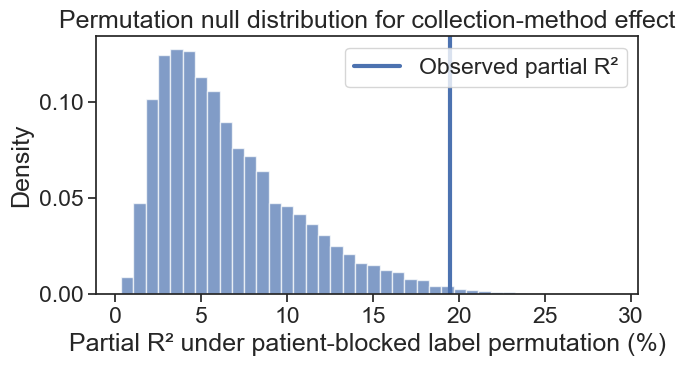

In [130]:
observed_partial_R2 = joint_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig('Permutation_histogram_transcriptomics_hcc.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Histogram shows the null distribution of partial R² values obtained by patient-blocked permutation of biopsy/resection labels. 
# The vertical line indicates the observed partial R². 
# Partial R² represents the fraction of residual PCA-space variance explained by collection method after accounting for patient identity.

In [131]:
2**14

16384

## 21. Joint assessment of sampling method and tumor content

Relate tumor-content change to PCA displacement and compare collection-label and tumor-content permutation null distributions.

In [133]:
from scipy.stats import spearmanr

tumor_content_col = "tumor"  # change if needed
patient_col = "patient_id"
n_perm = 16384 #2**14
random_seed = 42

diff_cols = [
    f"{pc}_resection_minus_biopsy"
    for pc in pc_cols
]

# ------------------------------------------------------------------
# Assemble paired PCA and tumour-content changes
# ------------------------------------------------------------------

tumor_content = pd.to_numeric(
    metadata_hcc[tumor_content_col].dropna(),
    errors="coerce",
)

analysis_df = paired_distances.copy()

analysis_df["biopsy_tumor_content"] = (
    analysis_df["biopsy_sample"].map(tumor_content)
)
analysis_df["resection_tumor_content"] = (
    analysis_df["resection_sample"].map(tumor_content)
)

# Signed change is needed for multivariate regression
analysis_df["tumor_content_delta"] = (
    analysis_df["resection_tumor_content"]
    - analysis_df["biopsy_tumor_content"]
)

# Absolute change is used for the magnitude correlation
analysis_df["tumor_content_change"] = (
    analysis_df["tumor_content_delta"].abs()
)

analysis_df["relative_pca_distance"] = (
    analysis_df["paired_distance"]
    / median_between_patient_distance
)

analysis_df = analysis_df.dropna(
    subset=[
        "tumor_content_delta",
        "relative_pca_distance",
        *diff_cols,
    ]
).copy()

if len(analysis_df) < 3:
    raise ValueError("At least three complete pairs are required.")

if analysis_df["tumor_content_delta"].nunique() < 2:
    raise ValueError("Tumour-content change has no variation.")

print(f"Complete pairs included: {len(analysis_df)}")

Complete pairs included: 14


In [134]:
spearman_rho, spearman_p = spearmanr(
    analysis_df["tumor_content_change"],
    analysis_df["relative_pca_distance"],
)

print(f"Spearman rho: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.4g}")

Spearman rho: 0.130
Spearman p-value: 0.6583


In [135]:
delta_tumor = analysis_df["tumor_content_delta"].to_numpy(dtype=float)
delta_pca = analysis_df[diff_cols].to_numpy(dtype=float)

# Multivariate OLS: one regression fitted jointly across all PC outcomes
X = np.column_stack([
    np.ones(len(delta_tumor)),
    delta_tumor,
])

coefficients, _, _, _ = np.linalg.lstsq(
    X,
    delta_pca,
    rcond=None,
)

sample_type_vector = coefficients[0]
tumor_content_slope = coefficients[1]

fitted_delta_pca = X @ coefficients
residual_delta_pca = delta_pca - fitted_delta_pca

# Multivariate R² across all included PCs
centered_delta_pca = delta_pca - delta_pca.mean(axis=0)

total_ss = np.sum(centered_delta_pca**2)
residual_ss = np.sum(residual_delta_pca**2)

multivariate_r2 = 1 - residual_ss / total_ss

# PCA-space effect sizes
sample_type_distance_adjusted = np.linalg.norm(
    sample_type_vector
)

tumor_distance_per_20_percent = np.linalg.norm(
    tumor_content_slope * 20
)

sample_type_relative_distance = (
    sample_type_distance_adjusted
    / median_between_patient_distance
)

tumor_relative_distance_per_20_percent = (
    tumor_distance_per_20_percent
    / median_between_patient_distance
)

In [136]:
def calculate_multivariate_r2(x, y):
    """R² for y ~ intercept + x, with multivariate y."""
    x_centered = x - x.mean()
    y_centered = y - y.mean(axis=0)

    x_ss = x_centered @ x_centered
    y_ss = np.sum(y_centered**2)

    slopes = (x_centered @ y_centered) / x_ss
    fitted_centered = np.outer(x_centered, slopes)

    return np.sum(fitted_centered**2) / y_ss


rng = np.random.default_rng(random_seed)
permuted_r2 = np.empty(n_perm)

for i in range(n_perm):
    permuted_delta = rng.permutation(delta_tumor)
    permuted_r2[i] = calculate_multivariate_r2(
        permuted_delta,
        delta_pca,
    )

multivariate_permutation_p = (
    1 + np.count_nonzero(permuted_r2 >= multivariate_r2)
) / (n_perm + 1)

In [137]:
multivariate_summary = pd.DataFrame({
    "n_pairs": [len(analysis_df)],
    "n_pcs": [len(pc_cols)],
    "multivariate_r_squared": [multivariate_r2],
    "permutation_p_value": [multivariate_permutation_p],
    "adjusted_sample_type_distance": [
        sample_type_distance_adjusted
    ],
    "adjusted_sample_type_relative_distance": [
        sample_type_relative_distance
    ],
    "tumor_content_distance_per_20_percentage_points": [
        tumor_distance_per_20_percent
    ],
    "tumor_content_relative_distance_per_20_percentage_points": [
        tumor_relative_distance_per_20_percent
    ],
})

coefficient_table = pd.DataFrame({
    "PC": pc_cols,
    "adjusted_biopsy_to_resection_effect": sample_type_vector,
    "effect_per_20_percentage_point_tumor_change":
        tumor_content_slope * 20,
})

display(multivariate_summary)
display(coefficient_table)

,n_pairs,n_pcs,multivariate_r_squared,permutation_p_value,adjusted_sample_type_distance,adjusted_sample_type_relative_distance,tumor_content_distance_per_20_percentage_points,tumor_content_relative_distance_per_20_percentage_points
0,14,10,0.121471,0.153433,4.149062,0.143707,2.405887,0.08333


,PC,adjusted_biopsy_to_resection_effect,effect_per_20_percentage_point_tumor_change
0,PC1,-3.402112,1.029691
1,PC2,-1.343267,1.104431
2,PC3,-0.319259,-1.024297
3,PC4,-0.512379,-0.639988
4,PC5,0.334909,0.105972
5,PC6,-0.721505,-1.321783
6,PC7,-0.164594,-0.453334
7,PC8,-0.170601,0.017423
8,PC9,1.665953,-0.292110
9,PC10,-0.084819,-0.003053


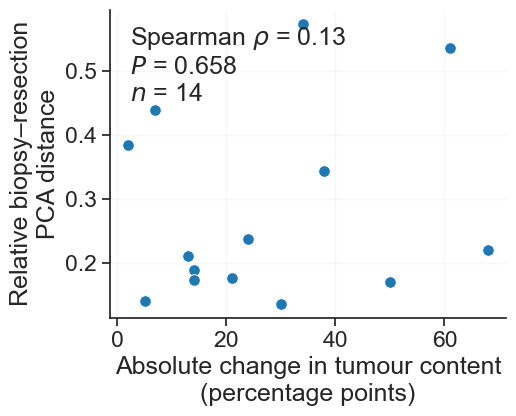

In [138]:
x = analysis_df["tumor_content_change"]
y = analysis_df["relative_pca_distance"]

rho, p_value = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.scatter(
    x,
    y,
    s=70,
    color="tab:blue",
    edgecolor="white",
    linewidth=0.7,
)

ax.text(
    0.05,
    0.95,
    (
        f"Spearman $\\rho$ = {rho:.2f}\n"
        f"$P$ = {p_value:.3f}\n"
        f"$n$ = {len(analysis_df)}"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
)

ax.set_xlabel(
    "Absolute change in tumour content\n"
    "(percentage points)"
)
ax.set_ylabel(
    "Relative biopsy–resection\nPCA distance"
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.15)
fig.tight_layout()

fig.savefig(
    "Tumor_content_vs_PCA_distance_simple.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

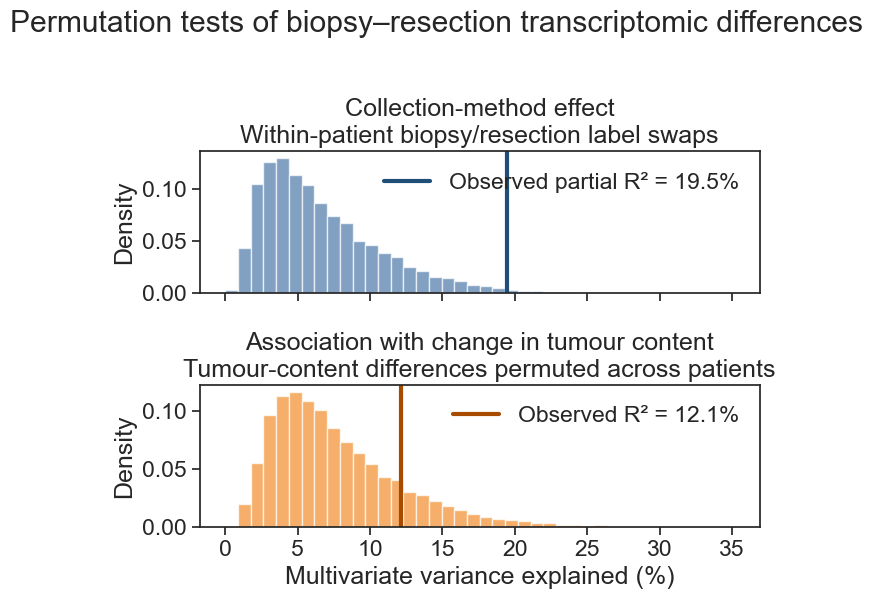

In [139]:
collection_null = perm_R2 * 100
tissue_null = permuted_r2 * 100

collection_observed = (
    joint_test_result["observed_partial_R2"] * 100
)
tissue_observed = multivariate_r2 * 100

# Common range and bin edges make visual comparison easier
x_max = max(
    collection_null.max(),
    tissue_null.max(),
    collection_observed,
    tissue_observed,
)

bins = np.linspace(0, x_max * 1.05, 41)

fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
)

# Collection-method test
axes[0].hist(
    collection_null,
    bins=bins,
    density=True,
    alpha=0.7,
    color="#4C78A8",
)

axes[0].axvline(
    collection_observed,
    color="#1F4E79",
    linewidth=3,
    label=f"Observed partial R² = {collection_observed:.1f}%",
)

axes[0].set_ylabel("Density")
axes[0].set_title(
    "Collection-method effect\n"
    "Within-patient biopsy/resection label swaps"
)
axes[0].legend(frameon=False)

# Tissue-composition test
axes[1].hist(
    tissue_null,
    bins=bins,
    density=True,
    alpha=0.7,
    color="#F28E2B",
)

axes[1].axvline(
    tissue_observed,
    color="#A64B00",
    linewidth=3,
    label=f"Observed R² = {tissue_observed:.1f}%",
)

axes[1].set_xlabel("Multivariate variance explained (%)")
axes[1].set_ylabel("Density")
axes[1].set_title(
    "Association with change in tumour content\n"
    "Tumour-content differences permuted across patients"
)
axes[1].legend(frameon=False)

fig.suptitle(
    "Permutation tests of biopsy–resection transcriptomic differences",
    y=1.01,
)

plt.tight_layout()
plt.savefig(
    "Permutation_histograms_collection_and_tissue_composition.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 22. HCC differential expression

Fit the paired tumor PyDESeq2 model and annotate the differential-expression results.

In [628]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 17.10 seconds.



In [629]:
dds.deseq2(fit_type='parametric')

Using parametric fit type.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.05 seconds.

Fitting dispersions...
... done in 14.99 seconds.

Fitting dispersion trend curve...
... done in 1.17 seconds.

Fitting MAP dispersions...
... done in 13.29 seconds.

Fitting LFCs...
... done in 9.79 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 0 outlier genes.



In [630]:
# cooksCutoff=FALSE, independentFiltering=FALSE
ds = DeseqStats(dds, contrast=['Sample_type', 'Resection', 'Biopsy'],
                cooks_filter=False, independent_filter=False)

In [631]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Sample_type Resection vs Biopsy
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000160072  406.515174       -0.165295  0.142438 -1.160470  0.245858   
ENSG00000142611   32.464489       -0.339947  0.352419 -0.964610  0.334740   
ENSG00000157911  238.596948       -0.376704  0.125479 -3.002126  0.002681   
ENSG00000142655  370.736111       -0.203846  0.143775 -1.417812  0.156246   
ENSG00000149527  141.829329       -0.654149  0.268586 -2.435535  0.014870   
...                     ...             ...       ...       ...       ...   
ENSG00000278384   56.266587       -0.106878  0.214451 -0.498378  0.618218   
ENSG00000275063   47.546019       -1.049059  0.576045 -1.821141  0.068585   
ENSG00000277856   83.134217       -0.363205  0.855643 -0.424482  0.671214   
ENSG00000271254  213.327746       -0.195787  0.216919 -0.902579  0.366749   
ENSG00000277475    4.531083        0.186102  0.678716  0.274197  0.783934   

     

... done in 14.24 seconds.



In [632]:
df_res_hcc = ds.results_df
df_res_hcc['abs_diff'] = df_res_hcc.log2FoldChange.abs()
df_res_hcc = df_res_hcc.sort_values('abs_diff', ascending=False)
df_res_hcc.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff
ENSG00000125740,158.579162,3.807542,0.534962,7.117413,1.099717e-12,1.657073e-09,3.807542
ENSG00000090104,2014.544335,3.272291,0.310844,10.527102,6.479883e-26,1.074041e-21,3.272291
ENSG00000111704,2.640435,3.142276,1.146025,2.741891,6.108670e-03,4.849196e-02,3.142276
ENSG00000163736,20.605629,-3.035057,0.678552,-4.472845,7.718555e-06,1.037530e-03,3.035057
ENSG00000244734,7295.142570,-2.986662,0.416719,-7.167085,7.661119e-13,1.410923e-09,2.986662


In [633]:
# Add Gene Names
with open('../../../ensemble_mappings_gene.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_n_h = df_res_hcc.reset_index(names='Geneid').copy()
    
df_n_h['Gene'] = df_n_h['Geneid'].map(loaded_dict)
df_n_h.Gene = df_n_h.Gene.replace('', np.nan)
df_n_h['Gene'] = np.where(df_n_h.Gene.isnull(), df_n_h.Geneid, df_n_h.Gene)
df_n_h.index = df_n_h.Geneid
df_n_h = df_n_h.drop('Geneid', axis=1)

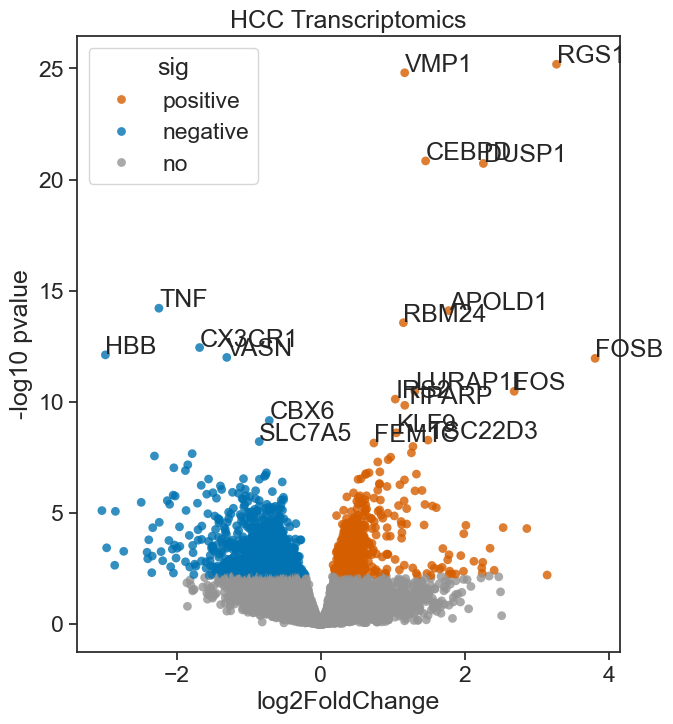

In [634]:
df_ttest_ = df_n_h.copy()

# Drop non-significant outlier
#df_ttest_ = df_ttest_[df_ttest_.Gene != 'SERPINB7']

df_ttest_['sig'] = np.where((df_ttest_['padj'] < 0.05) &\
                            (df_ttest_['log2FoldChange'] > 0), 'positive',
                    np.where((df_ttest_['padj'] < 0.05) &\
                             (df_ttest_['log2FoldChange'] < 0), 'negative', 
                                    'no'))
df_ttest_['-log10 pvalue'] = -np.log10(df_ttest_.pvalue)

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='log2FoldChange', y='-log10 pvalue',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pvalue', ascending=False)
                
most_sig['Gene'] = most_sig.index.map(loaded_dict)

for i in range(0,20):
    x = most_sig.iloc[i,:]['log2FoldChange'].item()
    y = most_sig.iloc[i,:]['-log10 pvalue'].item() + 0.05
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('HCC Transcriptomics')
#plt.show()
plt.savefig('figures/Volcano_rnaseq_hcc_output.pdf', bbox_inches='tight', dpi=300)

In [635]:
df_ttest_hcc = df_ttest_.copy()

In [639]:
df_ttest_.sort_values('abs_diff', ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue
Geneid,,,,,,,,,,
ENSG00000125740,158.579162,3.807542,0.534962,7.117413,1.099717e-12,1.657073e-09,3.807542,FOSB,positive,11.958719
ENSG00000090104,2014.544335,3.272291,0.310844,10.527102,6.479883e-26,1.074041e-21,3.272291,RGS1,positive,25.188433
ENSG00000111704,2.640435,3.142276,1.146025,2.741891,6.108670e-03,4.849196e-02,3.142276,NANOG,positive,2.214053
ENSG00000163736,20.605629,-3.035057,0.678552,-4.472845,7.718555e-06,1.037530e-03,3.035057,PPBP,negative,5.112464
ENSG00000244734,7295.142570,-2.986662,0.416719,-7.167085,7.661119e-13,1.410923e-09,2.986662,HBB,negative,12.115708
...,...,...,...,...,...,...,...,...,...,...
ENSG00000106785,1084.519528,0.000072,0.096087,0.000750,9.994019e-01,9.998242e-01,0.000072,TRIM14,no,0.000260
ENSG00000198354,5.513785,0.000057,0.772727,0.000074,9.999410e-01,9.999410e-01,0.000057,DCAF12L2,no,0.000026
ENSG00000179934,21.304958,-0.000042,0.256393,-0.000164,9.998693e-01,9.999296e-01,0.000042,CCR8,no,0.000057


In [640]:
df_sig_h = df_ttest_[df_ttest_.padj < 0.05].copy()

## 23. HCC pathway enrichment and export

Run Hallmark enrichment using the tested gene background and export the tumor results.

In [641]:
msig = Msigdb()
gmt = msig.get_gmt(category='h.all', dbver="2024.1.Hs")

In [642]:
# Define background set as all identified protein codeing genes
bg_genes = set(df_n_h['Gene'])
len(bg_genes)

16573

In [643]:
enr_res = gp.enrichr(gene_list=df_sig_h.Gene.tolist(),
 gene_sets=gmt,
 organism='Homo Sapiens',
 outdir='HM/',
 background=bg_genes,
 )

In [644]:
enr_res.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,gs_ind_0,HALLMARK_ADIPOGENESIS,28/197,3.130650e-01,6.522188e-01,1.141563,1.325748,PEMT;AGPAT3;ATL2;LIPE;PPM1B;SLC27A1;MIGA2;MRPL...
1,gs_ind_0,HALLMARK_ALLOGRAFT_REJECTION,41/190,5.280752e-04,1.320188e-02,1.899037,14.330652,CCR5;CD4;CXCR3;IFNG;GPR65;IL2RB;FLNA;LCK;TNF;I...
2,gs_ind_0,HALLMARK_ANDROGEN_RESPONSE,20/98,2.317422e-02,1.655301e-01,1.777541,6.691935,SPCS3;MAP7;FKBP5;ELL2;KRT19;TPD52;PMEPA1;SLC38...
3,gs_ind_0,HALLMARK_ANGIOGENESIS,3/34,8.307877e-01,9.912776e-01,0.752709,0.139538,NRP1;STC1;JAG2
4,gs_ind_0,HALLMARK_APICAL_JUNCTION,29/190,1.851838e-01,5.446581e-01,1.241436,2.093566,NF1;COL16A1;MYL9;EVL;SRC;SDC3;FLNC;FSCN1;GRB7;...
5,gs_ind_0,HALLMARK_APICAL_SURFACE,7/43,3.124167e-01,6.522188e-01,1.394135,1.621961,SULF2;ADIPOR2;CX3CL1;CROCC;ADAM10;IL2RB;B4GALT1
6,gs_ind_0,HALLMARK_APOPTOSIS,26/159,1.159331e-01,4.140470e-01,1.349803,2.908477,MCL1;SLC20A1;PLCB2;TNF;CD69;TXNIP;RHOB;IL1B;NE...
7,gs_ind_0,HALLMARK_BILE_ACID_METABOLISM,11/110,8.519430e-01,9.912776e-01,0.782216,0.125339,FADS2;LIPE;ABCA2;BMP6;BCAR3;PEX13;RXRA;NEDD4;L...
8,gs_ind_0,HALLMARK_CHOLESTEROL_HOMEOSTASIS,12/74,2.372943e-01,6.522188e-01,1.357706,1.952998,FADS2;ECH1;TP53INP1;ATF5;ERRFI1;ABCA2;NFIL3;LS...
9,gs_ind_0,HALLMARK_COAGULATION,10/134,9.832292e-01,9.912776e-01,0.569521,0.009632,C1QA;BMP1;PDGFB;PREP;CRIP2;LAMP2;COMP;MMP15;PL...


C:\Users\Fredrik\AppData\Local\Temp\ipykernel_26252\339411021.py:9: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)',


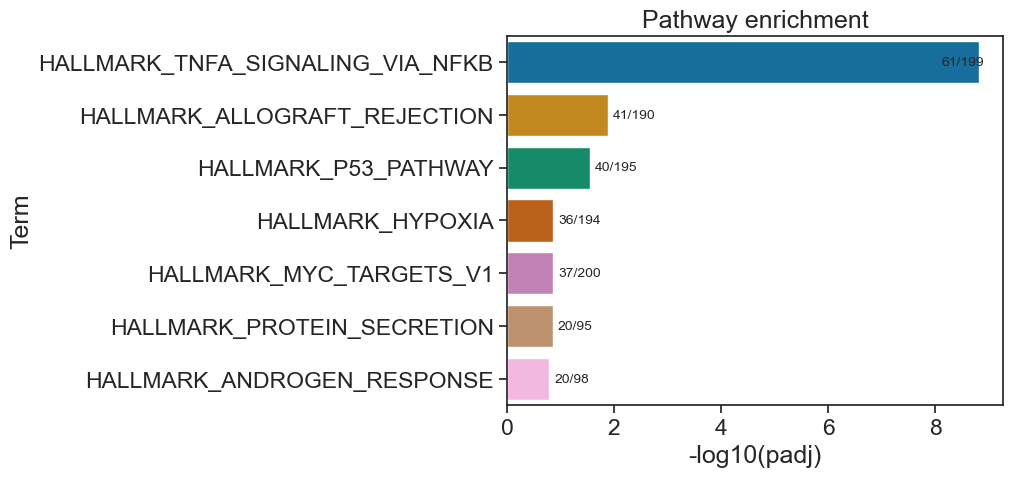

In [645]:
path_res = enr_res.results
path_res = path_res.sort_values('Adjusted P-value').reset_index(drop=True)

path_res['count'] = path_res.Overlap.str.split('/').str[0].astype(int) / path_res.Overlap.str.split('/').str[1].astype(int)
path_res['-log10(padj)'] = -np.log10(path_res['Adjusted P-value'])
path_res_sig = path_res[path_res['P-value'] < 0.05]

# Barplot
g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)', 
                   palette=sns.color_palette('colorblind'), orient='h')

# Annotate bars with Overlap values
for i, (bar, overlap) in enumerate(zip(g.patches, path_res_sig.iloc[:7]['Overlap'])):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if i == 0:
        width = width - .8
    g.text(width + 0.1, y, overlap, va='center', ha='left', fontsize=10)

plt.title('Pathway enrichment')
plt.savefig(f'figures/HM_hcc_rna_pathway_enrichment.pdf', bbox_inches='tight', dpi=300)
#plt.show()

In [646]:
# Extract genes in each pathway
pathway_genes = {}
for row in path_res_sig.iterrows():
    genes = set(row[1]['Genes'].split(';'))
    path = row[1]['Term']
    pathway_genes[path] = genes

Text(0.5, 0, 'log2FoldChange')

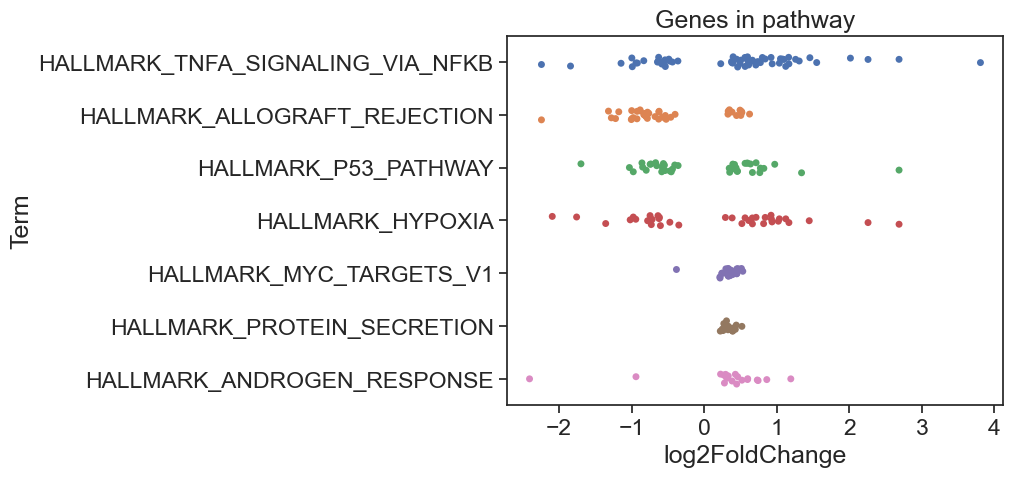

In [647]:
# Plot fold-change of genes identified in pathway enrichment

genes_list = []
for i in range(0,7):
    path = path_res_sig.Term[i]
    genes = pathway_genes[path]

    gene_data = df_sig_h[df_sig_h.Gene.isin(genes)].log2FoldChange
    genes_list.append(gene_data)
    
df_path_genes = pd.concat(genes_list, axis=1)
df_path_genes.columns = path_res_sig.Term[0:7]
#df_path_genes.head()

sns.stripplot(data=df_path_genes, orient='h')
plt.title('Genes in pathway')
plt.xlabel('log2FoldChange')
#plt.savefig(f'figures/HM_hcc_rna_pathway_FC.pdf', bbox_inches='tight', dpi=300)

In [648]:
df_path_genes.head()

Term,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_P53_PATHWAY,HALLMARK_HYPOXIA,HALLMARK_MYC_TARGETS_V1,HALLMARK_PROTEIN_SECRETION,HALLMARK_ANDROGEN_RESPONSE
Geneid,,,,,,,
ENSG00000125740,3.807542,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000170345,2.685365,NaN,2.685365,2.685365,NaN,NaN,NaN
ENSG00000120129,2.257792,NaN,NaN,2.257792,NaN,NaN,NaN
ENSG00000232810,-2.244320,-2.24432,NaN,NaN,NaN,NaN,NaN
ENSG00000109321,2.015039,NaN,NaN,NaN,NaN,NaN,NaN


In [649]:
# Create output csv file

# Populate export table with pathway gene identity

hm_dict = {}

for row in path_res.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in hm_dict.keys():
            prev_term = hm_dict[gene]
            prev_term.append(term)
            hm_dict[gene] = prev_term
        else:
            hm_dict[gene] = [term]
            
df_ttest_['Hallmark'] = df_ttest_.Gene.map(hm_dict)
df_ttest_.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
Geneid,,,,,,,,,,,
ENSG00000125740,158.579162,3.807542,0.534962,7.117413,1.099717e-12,1.657073e-09,3.807542,FOSB,positive,11.958719,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_UV..."
ENSG00000090104,2014.544335,3.272291,0.310844,10.527102,6.479883e-26,1.074041e-21,3.272291,RGS1,positive,25.188433,[HALLMARK_INFLAMMATORY_RESPONSE]
ENSG00000111704,2.640435,3.142276,1.146025,2.741891,6.108670e-03,4.849196e-02,3.142276,NANOG,positive,2.214053,NaN
ENSG00000163736,20.605629,-3.035057,0.678552,-4.472845,7.718555e-06,1.037530e-03,3.035057,PPBP,negative,5.112464,[HALLMARK_KRAS_SIGNALING_UP]
ENSG00000244734,7295.142570,-2.986662,0.416719,-7.167085,7.661119e-13,1.410923e-09,2.986662,HBB,negative,12.115708,[HALLMARK_HEME_METABOLISM]


In [650]:
df_hcc_out = pd.concat([df_hcc, df_ttest_], axis=1)
df_hcc_out.head()

,BSSE_QGF_129467,BSSE_QGF_182053,BSSE_QGF_145477,BSSE_QGF_145473,BSSE_QGF_129477,BSSE_QGF_182073,BSSE_QGF_182065,BSSE_QGF_129475,BSSE_QGF_145461,BSSE_QGF_182055,...,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
ENSG00000160072,8.087017,8.342778,9.721116,7.779847,7.964220,9.663918,9.444492,8.597433,8.313341,8.340976,...,-0.165295,0.142438,-1.160470,0.245858,0.454708,0.165295,ATAD3B,no,0.609316,NaN
ENSG00000142611,4.827391,4.810591,5.120588,5.172637,6.405881,5.586655,6.328679,5.301185,5.282743,5.524255,...,-0.339947,0.352419,-0.964610,0.334740,0.547820,0.339947,PRDM16,no,0.475292,NaN
ENSG00000157911,7.876716,8.027148,8.389657,8.592955,7.096751,7.916985,8.601629,8.308721,8.222739,7.613065,...,-0.376704,0.125479,-3.002126,0.002681,0.030813,0.376704,PEX10,negative,2.571702,NaN
ENSG00000142655,6.896657,8.729402,8.939685,9.433079,7.987384,9.142334,9.018697,9.000283,9.515011,8.187141,...,-0.203846,0.143775,-1.417812,0.156246,0.348116,0.203846,PEX14,no,0.806192,NaN
ENSG00000149527,5.957286,7.187998,9.744854,7.237911,8.518742,7.429149,7.379030,5.759340,6.279460,6.492262,...,-0.654149,0.268586,-2.435535,0.014870,0.081855,0.654149,PLCH2,no,1.827695,NaN


In [651]:
df_hcc_out.to_csv('RNA_hcc_output_29072026.csv')

## 24. Cross-tissue significant-gene overlap

Generate the Venn diagram used to compare significant genes between non-tumor liver and HCC. Fold-change correlation branches were removed because the final manuscript explicitly omits them.

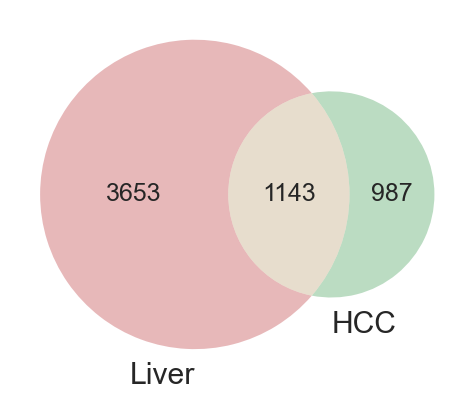

In [652]:
from matplotlib_venn import venn2

set1 = set(df_sig_l.Gene)
set2 = set(df_sig_h.Gene)

venn2([set1, set2], ('Liver', 'HCC'))

plt.savefig('figures/Venn_sig_degs_liver_vs_hcc.pdf', dpi=300, bbox_inches='tight')